---
title: "MasterControl -Lead Scoring & Conversion Optimization"
subtitle: "Group Modeling Notebook: Feature Engineering, Model Selection & Business Impact"
author: "Thomas Beck · Max Ridgeway · Astha KC"
date: "Spring 2026"
format:
  html:
    embed-resources: true
    theme: flatly
    highlight-style: tango
    toc: true
    toc-depth: 3
    toc-location: left
    number-sections: true
    df-print: paged
    code-fold: true
    code-tools: true
  pdf:
    documentclass: article
    geometry:
      - top=0.6in
      - bottom=0.6in
      - left=0.6in
      - right=0.6in
    fontsize: 10pt
    toc: true
    toc-depth: 2
    number-sections: true
    colorlinks: true
    code-fold: true
    fig-pos: "H"
    keep-tex: false
execute:
  echo: true
  warning: false
  message: false
  fig-width: 7.5
  fig-height: 4.5
  fig-dpi: 200
  out-width: "100%"
editor_options:
  chunk_output_type: inline
---

# Table of Contents
1. [Introduction](#Introduction)
2. [Methodology](#Methodology)
3. [Data Preparation and Feature Engineering](#Data-Preparation-and-Feature-Engineering)
4. [Model Analysis](#Model-Analysis)
5. [Test Set Evaluation](#Test-Set-Evaluation)
6. [SHAP Explainability](#SHAP-Explainability)
7. [Profit Analysis](#Profit-Analysis)
8. [Sponsor Q and A Validation](#Sponsor-Q-and-A-Validation)
9. [Results and Conclusion](#Results-and-Conclusion)
10. [Group Members and Contributions](#Group-Members-and-Contributions)

In [87]:
%pip install pandas
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import (GradientBoostingClassifier, RandomForestClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score

# If you are using imbalanced-learn for SMOTE and the pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedBaggingClassifier

# Make sure your constants are defined too!
RANDOM_STATE = 42
N_ITER_SEARCH = 10 # or whatever value you prefer

from sklearn.model_selection import StratifiedKFold

# Define the Cross-Validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.


In [60]:
#| label: setup
#| include: false

import subprocess, sys, warnings, time, re, multiprocessing
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
np.random.seed(42)
START_TIME = time.time()

# Reserve 2 cores for other tasks
N_JOBS = max(1, multiprocessing.cpu_count() - 2)

In [61]:
#| label: dependencies
#| include: false

def install_if_missing(package_name, import_name=None, pip_name=None):
    import_name = import_name or package_name.lower()
    pip_name = pip_name or import_name
    try:
        __import__(import_name)
    except ImportError:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", pip_name, "-q"],
            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

for pkg in [
    ("scikit-learn", "sklearn", "scikit-learn"),
    ("pyprojroot", None, None),
    ("CatBoost", "catboost", None),
    ("XGBoost", "xgboost", None),
    ("LightGBM", "lightgbm", None),
    ("SHAP", "shap", None),
    ("matplotlib", None, None),
    ("seaborn", None, None),
    ("tabulate", None, None),
    ("imbalanced-learn", "imblearn", "imbalanced-learn"),
]:
    install_if_missing(*pkg)

In [62]:
#| label: imports
#| include: false

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from pyprojroot import here
from types import SimpleNamespace
from tabulate import tabulate

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    RandomizedSearchCV, cross_val_predict,
)
from sklearn.preprocessing import (
    StandardScaler, LabelEncoder,
    FunctionTransformer, OrdinalEncoder,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import (
    BaseEstimator, TransformerMixin,
    ClassifierMixin, clone,
)
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    classification_report, confusion_matrix,
    brier_score_loss, log_loss,
    f1_score, precision_score, recall_score,
)
from sklearn.calibration import (
    CalibratedClassifierCV, calibration_curve,
)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    StackingClassifier, VotingClassifier,
)
from sklearn.linear_model import LogisticRegression

SMOTE_AVAILABLE = False
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    pass

In [63]:
#| label: configuration
#| include: false

RANDOM_STATE = 42
CV_FOLDS = 5
N_ITER_SEARCH = 100
TEST_SIZE = 0.10
VAL_SIZE = 0.10

LSA_COMPONENTS = 20
TFIDF_MAX_FEATURES = 500

COST_PER_CALL = 50
VALUE_PER_SQL = 6000

SHAP_BACKGROUND_SAMPLES = 100
SHAP_TEST_SAMPLES = 200

COL_SUCCESS = '#00534B'
COL_RISK    = '#F05627'
COL_NEUTRAL = '#95a5a6'
COL_ACCENT  = '#2980b9'
COL_GOLD    = '#f39c12'
COL_PROFIT  = '#27ae60'
COL_LOWVAL  = '#e74c3c'
COL_PREMIUM = '#2ecc71'

MODEL_COLORS = {
    'CatBoost':          '#1b9e77',
    'XGBoost':           '#d95f02',
    'LightGBM':          '#7570b3',
    'GradientBoosting':  '#e7298a',
    'RandomForest':      '#66a61e',
    'StackingEnsemble':  '#00534B',
    'VotingEnsemble':    '#e6ab02',
}

# PDF-friendly defaults
sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (7.5, 4.5),
    'figure.dpi': 200,
    'axes.titleweight': 'bold',
    'font.family': 'sans-serif',
    'figure.autolayout': True,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
})

def print_table(data, caption="", fmt="pipe"):
    if isinstance(data, pd.DataFrame):
        print(f"\n**{caption}**\n" if caption else "")
        print(data.to_markdown(index=False))
    else:
        print(data)

DATA_DIR = here("data")
OUTPUT_DIR = here("output")
CLEANED_DATA_PATH = here(
    "output/Cleaned_QAL_Performance_for_MSBA.csv"
)
RAW_DATA_PATH = here(
    "data/QAL Performance for MSBA.csv"
)
DATA_PATH = (
    CLEANED_DATA_PATH
    if CLEANED_DATA_PATH.exists()
    else RAW_DATA_PATH
)

In [64]:
#| label: catboost-wrapper
#| include: false
#| echo: false

CATBOOST_AVAILABLE = False
try:
    from catboost import CatBoostClassifier as CatBoostRaw

    class SklearnCatBoost(BaseEstimator, ClassifierMixin):
        _estimator_type = "classifier"

        def __init__(
            self, iterations=500, depth=6,
            learning_rate=0.1, l2_leaf_reg=3,
            border_count=64, random_state=42,
            verbose=0, thread_count=1,
        ):
            self.iterations = iterations
            self.depth = depth
            self.learning_rate = learning_rate
            self.l2_leaf_reg = l2_leaf_reg
            self.border_count = border_count
            self.random_state = random_state
            self.verbose = verbose
            self.thread_count = thread_count
            self._model = None

        def __sklearn_tags__(self):
            tags = SimpleNamespace()
            tags.estimator_type = "classifier"
            tags.classifier_tags = SimpleNamespace()
            tags.regressor_tags = None
            tags.transformer_tags = None
            tags.input_tags = SimpleNamespace(
                allow_nan=True, pairwise=False,
                one_d_labels=True, two_d_labels=False,
            )
            tags.target_tags = SimpleNamespace(
                required_y=True, one_d_labels=True,
                two_d_labels=False,
            )
            return tags

        def fit(self, X, y, **kw):
            self._model = CatBoostRaw(
                iterations=self.iterations,
                depth=self.depth,
                learning_rate=self.learning_rate,
                l2_leaf_reg=self.l2_leaf_reg,
                border_count=self.border_count,
                random_state=self.random_state,
                verbose=self.verbose,
                thread_count=self.thread_count,
                allow_writing_files=False,
            )
            self._model.fit(X, y, **kw)
            self.classes_ = np.unique(y)
            return self

        def predict(self, X):
            return (
                self._model.predict(X)
                .flatten().astype(int)
            )

        def predict_proba(self, X):
            return self._model.predict_proba(X)

        @property
        def feature_importances_(self):
            return self._model.get_feature_importance()

    CATBOOST_AVAILABLE = True
except ImportError:
    pass

XGBOOST_AVAILABLE = False
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    pass

LIGHTGBM_AVAILABLE = False
try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except ImportError:
    pass

TARGET_ENCODER_AVAILABLE = False
try:
    from sklearn.preprocessing import TargetEncoder
    TARGET_ENCODER_AVAILABLE = True
except ImportError:
    pass

SHAP_AVAILABLE = False
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    pass

# Introduction

## Business Problem

MasterControl sells quality management software to regulated
industries through two product lines: **Mx** (manufacturing
execution) and **Qx** (quality management). Leads enter the
pipeline as Qualified Activity Leads (QALs) and progress through
stages - Disqualified, Recycled, SQL, SQO, or Won.

The core challenge is **conversion efficiency**. Mx converts at
roughly 12.7% versus 19.7% for Qx - a 7 percentage-point gap.
With a \$50 cost per sales call and \$6,000 value per SQL
conversion, the ability to identify which leads are most likely to
convert has direct revenue impact.

## Analytic Problem

This is a **binary classification** task with severe class
imbalance (~85% negative). A naive model that predicts "no
conversion" for every lead achieves 85% accuracy but provides zero
business value. Accuracy is therefore the wrong metric.

The analytic objective is to **rank leads by conversion
probability** using AUC-ROC as the primary evaluation metric. A
lead scoring model must:

1. Beat a logistic regression benchmark on held-out validation data.
2. Generalize to unseen test data without significant performance
   degradation (generalization gap < 0.05 AUC).
3. Translate predicted probabilities into a dollar-denominated
   profit curve that identifies the optimal number of leads to
   contact.

The deliverable is a scored lead list that lets the sales team
allocate effort toward the highest-value opportunities rather than
working the pipeline uniformly.

# Methodology

The CRISP-DM framework structures the analysis:

- **Data Preparation:** Raw CRM data is loaded, column names
  standardized, and missing categoricals imputed.
- **Feature Engineering:** Six domain-informed features plus
  temporal decay, ordinal seniority encoding, and interaction terms.
- **Modeling:** Five gradient boosting models are tuned via
  randomized search (100 iterations, 5-fold stratified CV), then
  combined in stacking and voting ensembles.
- **Evaluation:** AUC-ROC is the primary metric. Profit curves
  translate model scores into dollar-denominated business impact.

# Data Preparation and Feature Engineering

In [65]:
#| label: feature-definitions
#| output: false

# Domain knowledge maps for feature engineering
# Each map encodes business logic from MasterControl's sales process

INTENT_STRENGTH_MAP = {
    'P1 - Website Pricing': 5,
    'P1 - Contact Us': 5,
    'P1 - Video Demo': 3,
    'P1 - Live Demo': 3,
    'P1 - Webinar Demo': 1,
    'No Priority': 1,
    'Priority 1': 2,
    'Priority 2': 0,
}

CHANNEL_TIER_MAP = {
    'Direct/Inbound': 'Premium',
    'SEO': 'Premium',
    'Referrals': 'Premium',
    'Online Ads': 'Standard',
    'Directory Listing': 'Standard',
    'Events': 'Standard',
    'Outbound Prospecting': 'Standard',
    'Email': 'Low-Value',
    'External Demand Gen': 'Low-Value',
}
CHANNEL_NUMERIC_MAP = {
    'Premium': 3, 'Standard': 2,
    'Low-Value': 1, 'Unknown': 2,
}

INDUSTRY_BUDGET_MULTIPLIER = {
    'Pharma & BioTech': 3.0,
    'Blood & Biologics': 2.5,
    'Medical Device': 2.0,
    'Non-Life Science': 1.0,
    'Consumer Packaged Goods': 0.8,
}
TIER_SIZE_MAP = {
    'Small': 50, 'Medium': 500, 'Large': 5000,
}

PRODUCT_ROLE_ALIGNMENT = {
    'Mx': ['Op', 'Mfg', 'Manuf', 'Production', 'Plant'],
    'Qx': ['Qual', 'QA', 'QC', 'Compliance', 'Validation'],
}

HIGH_VALUE_BIGRAMS = [
    'continuous improvement', 'document control',
    'process engineer', 'quality systems',
    'regulatory affairs', 'quality assurance',
    'validation engineer', 'compliance manager',
]

# Ordinal maps for proper rank encoding
SENIORITY_ORDER = [
    'Unknown', 'Other', 'IC', 'Manager',
    'Director', 'VP', 'SVP', 'C-Suite',
]
SCOPE_ORDER = ['Standard', 'Site', 'Regional', 'Global']

The raw CRM export contains 16,816 QAL records with account
attributes (industry, tier, territory), contact attributes (title,
priority), channel source, and pipeline stage. The feature
engineering pipeline creates **six domain-informed signals** plus
temporal decay, ordinal seniority encoding, and interaction terms.

In [66]:
#| label: data-pipeline
#| output: false

# Load raw CRM data, standardize columns, and build all engineered features
def clean_and_engineer(filepath):
    df = pd.read_csv(filepath)
    df.columns = [
        c.strip().lower()
        .replace(' ', '_')
        .replace('/', '_')
        .replace('-', '_')
        for c in df.columns
    ]

    # --- Target ---
    if 'is_success' not in df.columns:
        df['is_success'] = (
            df['next_stage__c']
            .isin(['SQL', 'SQO', 'Won'])
            .astype(int)
        )

    # --- Feature 1: Intent Strength ---
    if 'priority' in df.columns:
        df['intent_strength'] = (
            df['priority']
            .map(INTENT_STRENGTH_MAP).fillna(1)
        )
    else:
        df['intent_strength'] = 1

    # --- Feature 2: Channel Efficiency ---
    ch_col = (
        'last_tactic_campaign_channel'
        if 'last_tactic_campaign_channel' in df.columns
        else 'lead_source'
    )
    if ch_col in df.columns:
        df['channel_tier'] = (
            df[ch_col].map(CHANNEL_TIER_MAP)
            .fillna('Standard')
        )
        df['channel_efficiency'] = (
            df['channel_tier']
            .map(CHANNEL_NUMERIC_MAP)
        )
    else:
        df['channel_tier'] = 'Standard'
        df['channel_efficiency'] = 2

    # --- Feature 3: Hidden Gem Flag ---
    m_col = (
        'acct_manufacturing_model'
        if 'acct_manufacturing_model' in df.columns
        else None
    )
    i_col = (
        'acct_target_industry'
        if 'acct_target_industry' in df.columns
        else None
    )
    s_col = (
        'acct_primary_site_function'
        if 'acct_primary_site_function' in df.columns
        else None
    )
    gem = pd.Series(False, index=df.index)
    if m_col:
        gem |= df[m_col].str.contains(
            'Not Enough Info', case=False, na=False
        )
    if s_col:
        gem |= df[s_col].str.contains(
            'Non-manufacturing', case=False, na=False
        )
    if i_col:
        gem |= df[i_col].str.contains(
            'Non-manufacturing', case=False, na=False
        )
    df['is_hidden_gem'] = gem.astype(int)

    # --- Feature 4: Capital Density Score ---
    t_col = (
        'acct_tier_rollup'
        if 'acct_tier_rollup' in df.columns
        else None
    )
    if i_col and t_col:
        df['_ind_mult'] = df[i_col].map(
            lambda x: next(
                (v for k, v
                 in INDUSTRY_BUDGET_MULTIPLIER.items()
                 if k.lower() in str(x).lower()),
                1.0,
            )
        )
        df['_tier_size'] = (
            df[t_col].map(TIER_SIZE_MAP).fillna(500)
        )
        df['capital_density_score'] = (
            df['_ind_mult'] * df['_tier_size']
        )
        df['capital_density_log'] = np.log1p(
            df['capital_density_score']
        )
        df.drop(
            columns=['_ind_mult', '_tier_size',
                     'capital_density_score'],
            errors='ignore', inplace=True,
        )
    else:
        df['capital_density_log'] = np.log1p(500)

    # --- Feature 5: Role-Product Match (continuous) ---
    title_col = (
        'contact_lead_title'
        if 'contact_lead_title' in df.columns
        else None
    )
    p_col = (
        'product_segment'
        if 'product_segment' in df.columns
        else 'solution_rollup'
    )
    if 'product_segment' not in df.columns:
        df['product_segment'] = df['solution_rollup'].apply(
            lambda s: (
                'Mx' if str(s) == 'Mx'
                else ('Qx' if str(s) == 'Qx'
                      else 'Other')
            )
        )
    if title_col and p_col in df.columns:
        def _role_match(row):
            title = (
                str(row[title_col]).lower()
                if pd.notna(row[title_col]) else ''
            )
            product = (
                str(row[p_col])
                if pd.notna(row[p_col]) else ''
            )
            if product in PRODUCT_ROLE_ALIGNMENT:
                hits = sum(
                    1 for kw
                    in PRODUCT_ROLE_ALIGNMENT[product]
                    if kw.lower() in title
                )
                return hits
            return 0
        df['role_product_match'] = df.apply(
            _role_match, axis=1
        )
    else:
        df['role_product_match'] = 0

    # --- Feature 6: Title Bigrams ---
    if title_col and title_col in df.columns:
        for bigram in HIGH_VALUE_BIGRAMS:
            col_name = 'has_' + bigram.replace(' ', '_')
            df[col_name] = (
                df[title_col].str.lower()
                .str.contains(bigram, na=False)
                .astype(int)
            )
        bg_cols = [
            c for c in df.columns if c.startswith('has_')
        ]
        df['title_bigram_count'] = df[bg_cols].sum(axis=1)
    else:
        df['title_bigram_count'] = 0

    # --- Title Parsing ---
    if (
        'title_seniority' not in df.columns
        and title_col
        and title_col in df.columns
    ):
        def _seniority(t):
            if pd.isna(t):
                return 'Unknown'
            t = str(t).lower()
            if re.search(
                r'\b(ceo|cfo|coo|cto|cio|chief|'
                r'c-level|president)\b', t
            ):
                return 'C-Suite'
            if re.search(
                r'\b(svp|senior vice president|evp)\b', t
            ):
                return 'SVP'
            if re.search(
                r'\b(vp|vice president)\b', t
            ):
                return 'VP'
            if re.search(
                r'\b(director|head of)\b', t
            ):
                return 'Director'
            if re.search(
                r'\b(manager|mgr|supervisor|lead)\b', t
            ):
                return 'Manager'
            if re.search(
                r'\b(analyst|engineer|specialist|'
                r'associate|coordinator)\b', t
            ):
                return 'IC'
            return 'Other'

        def _function(t):
            if pd.isna(t):
                return 'Unknown'
            t = str(t).lower()
            if re.search(
                r'\b(quality|qa|qc|qms|compliance|'
                r'validation|capa)\b', t
            ):
                return 'Quality'
            if re.search(
                r'\b(regulatory|reg affairs|'
                r'submissions)\b', t
            ):
                return 'Regulatory'
            if re.search(
                r'\b(manufacturing|production|'
                r'operations|ops|plant|supply)\b', t
            ):
                return 'Mfg/Ops'
            if re.search(
                r'\b(it|information tech|software|'
                r'systems|data)\b', t
            ):
                return 'IT'
            if re.search(
                r'\b(r&d|research|development|'
                r'scientist|clinical|lab)\b', t
            ):
                return 'R&D'
            if re.search(
                r'\b(project|program|pmo)\b', t
            ):
                return 'PMO'
            return 'Other'

        def _scope(t):
            if pd.isna(t):
                return 'Standard'
            t = str(t).lower()
            if re.search(
                r'\b(global|worldwide|international|'
                r'corporate|enterprise)\b', t
            ):
                return 'Global'
            if re.search(
                r'\b(regional|division|group)\b', t
            ):
                return 'Regional'
            if re.search(
                r'\b(site|plant|facility|local)\b', t
            ):
                return 'Site'
            return 'Standard'

        df['title_seniority'] = (
            df[title_col].apply(_seniority)
        )
        df['title_function'] = (
            df[title_col].apply(_function)
        )
        df['title_scope'] = (
            df[title_col].apply(_scope)
        )

    # --- NEW: Ordinal seniority & scope encoding ---
    if 'title_seniority' in df.columns:
        sen_map = {
            v: i for i, v in enumerate(SENIORITY_ORDER)
        }
        df['seniority_rank'] = (
            df['title_seniority'].map(sen_map).fillna(0)
        )
    if 'title_scope' in df.columns:
        sco_map = {
            v: i for i, v in enumerate(SCOPE_ORDER)
        }
        df['scope_rank'] = (
            df['title_scope'].map(sco_map).fillna(0)
        )

    # --- Decision maker ---
    if 'is_decision_maker' not in df.columns:
        df['is_decision_maker'] = (
            df['title_seniority']
            .isin(['C-Suite', 'SVP', 'VP', 'Director'])
            .astype(int)
        )

    # --- Title specificity (word count) ---
    if title_col and title_col in df.columns:
        df['title_word_count'] = (
            df[title_col].fillna('')
            .apply(lambda x: len(str(x).split()))
        )

    # --- Temporal features ---
    if (
        'cohort_date' in df.columns
        or 'qal_cohort_date' in df.columns
    ):
        cohort_src = (
            'qal_cohort_date'
            if 'qal_cohort_date' in df.columns
            else 'cohort_date'
        )
        df['cohort_date'] = pd.to_datetime(
            df[cohort_src], errors='coerce'
        )
        if 'lead_age_days' not in df.columns:
            df['lead_age_days'] = (
                df['cohort_date'].max()
                - df['cohort_date']
            ).dt.days

    if 'lead_age_days' in df.columns:
        df['velocity_tier'] = pd.cut(
            df['lead_age_days'].fillna(0),
            bins=[-1, 30, 60, 90, 180, 9999],
            labels=['Hot', 'Warm', 'Cooling',
                    'Cold', 'Stale'],
        ).astype(str)
        df['is_fresh'] = (
            (df['lead_age_days'] <= 30).astype(int)
        )
        df['is_stale'] = (
            (df['lead_age_days'] > 180).astype(int)
        )
        # NEW: exponential decay
        df['lead_age_decay'] = np.exp(
            -df['lead_age_days'].fillna(0) / 90
        )

    # --- Interaction features ---
    sen_c = (
        'title_seniority'
        if 'title_seniority' in df.columns else None
    )
    ind_c = (
        'acct_target_industry'
        if 'acct_target_industry' in df.columns
        else None
    )
    mod_c = (
        'acct_manufacturing_model'
        if 'acct_manufacturing_model' in df.columns
        else None
    )
    if sen_c and ind_c and mod_c:
        df['seniority_x_industry'] = (
            df[sen_c].astype(str) + '_'
            + df[ind_c].astype(str)
        )
        df['seniority_x_model'] = (
            df[sen_c].astype(str) + '_'
            + df[mod_c].astype(str)
        )
        df['industry_x_model'] = (
            df[ind_c].astype(str) + '_'
            + df[mod_c].astype(str)
        )
        df['power_trio'] = (
            df[sen_c].astype(str) + '_'
            + df[ind_c].astype(str) + '_'
            + df[mod_c].astype(str)
        )
        senior = df[sen_c].isin(
            ['Director', 'VP', 'SVP', 'C-Suite']
        )
        pharma = df[ind_c].str.contains(
            'Pharma|Life|Bio', case=False, na=False
        )
        inhouse = df[mod_c].str.contains(
            'In-House|In House|Inhouse',
            case=False, na=False,
        )
        df['is_golden_segment'] = (
            (senior & pharma & inhouse).astype(int)
        )
        df['is_senior_pharma'] = (
            (senior & pharma).astype(int)
        )

    if 'title_scope' in df.columns:
        df['is_global_scope'] = (
            (df['title_scope'] == 'Global').astype(int)
        )

    # NEW: industry-channel synergy
    if ind_c and 'channel_tier' in df.columns:
        df['industry_channel_synergy'] = (
            (
                df[ind_c].str.contains(
                    'Pharma|Bio', case=False, na=False
                )
                & (df['channel_tier'] == 'Premium')
            ).astype(int)
        )

    # NEW: seniority × decision-relevance weighting
    if 'title_function' in df.columns:
        decision_funcs = ['Quality', 'Regulatory']
        df['is_decision_relevant'] = (
            (
                df['is_decision_maker'].eq(1)
                & df['title_function'].isin(decision_funcs)
            ).astype(int)
        )

    # Fill missing categoricals
    for col in [
        'acct_manufacturing_model',
        'acct_primary_site_function',
        'acct_target_industry',
        'acct_territory_rollup',
        'title_seniority', 'title_function',
        'title_scope', 'channel_tier',
    ]:
        if col in df.columns:
            df[col] = df[col].fillna('Unknown')

    return df

df = clean_and_engineer(DATA_PATH)

In [67]:
print(df.columns.tolist())

['qal_id', 'contact_lead_id', 'is_success', 'outcome_tier', 'next_stage__c', 'product_segment', 'solution_rollup', 'acct_target_industry', 'acct_manufacturing_model', 'acct_primary_site_function', 'acct_territory_rollup', 'acct_tier_rollup', 'contact_lead_title', 'title_seniority', 'title_function', 'title_scope', 'is_decision_maker', 'record_completeness', 'completeness_tier', 'priority', 'last_tactic_campaign_channel', 'cohort_date', 'cohort_year', 'cohort_quarter', 'lead_age_days', 'intent_strength', 'channel_tier', 'channel_efficiency', 'is_hidden_gem', 'capital_density_log', 'role_product_match', 'has_continuous_improvement', 'has_document_control', 'has_process_engineer', 'has_quality_systems', 'has_regulatory_affairs', 'has_quality_assurance', 'has_validation_engineer', 'has_compliance_manager', 'title_bigram_count', 'seniority_rank', 'scope_rank', 'title_word_count', 'velocity_tier', 'is_fresh', 'is_stale', 'lead_age_decay', 'seniority_x_industry', 'seniority_x_model', 'industr

### Creating The "Buying Committee" Density (Aggregation) Variable

In [68]:
import numpy as np
import pandas as pd

def engineer_buying_committee_nuclear(df):
    # 1. Configuration
    ID_COL = 'contact_lead_id' 
    DATE_COL = 'cohort_date'
    
    # Standardize dates and sort
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')
    df = df.sort_values([ID_COL, DATE_COL]).reset_index(drop=True)

    # --- 2. account_penetration_count (Numpy Loop) ---
    dates = df[DATE_COL].values
    ids = df[ID_COL].values
    res = []
    
    for i in range(len(df)):
        lookback_limit = dates[i] - np.timedelta64(90, 'D')
        window = 0
        for j in range(i, -1, -1):
            if ids[j] != ids[i] or dates[j] < lookback_limit:
                break
            window += 1
        res.append(window)
    
    df['account_penetration_count'] = res

    # --- 3. has_cross_functional_interest (Corrected Logic) ---
    # Create the boolean flags first
    df['_is_mx'] = df['product_segment'].str.contains('Mx', na=False)
    df['_is_qx'] = df['product_segment'].str.contains('Qx', na=False)
    
    # We group by ID and check if "any" row in that group is True for each product
    has_mx_in_acct = df.groupby(ID_COL)['_is_mx'].transform('any')
    has_qx_in_acct = df.groupby(ID_COL)['_is_qx'].transform('any')
    
    # Combine them: True if the account has BOTH anywhere in their history
    df['has_cross_functional_interest'] = (has_mx_in_acct & has_qx_in_acct).astype(int)

    # Drop the temporary helper columns
    df.drop(columns=['_is_mx', '_is_qx'], inplace=True)

    return df

# Run the fixed function
df = engineer_buying_committee_nuclear(df)

# Check results
# Refer to the string name directly
print(df[['contact_lead_id', 'account_penetration_count', 'has_cross_functional_interest']].head())

      contact_lead_id  account_penetration_count  \
0  0030c00002XPeNGAA1                          1   
1  0030c00002XR1uPAAT                          1   
2  0030c00002Y3NUZAA3                          1   
3  0030c00002Y3NUZAA3                          1   
4  0030c00002Z2FgfAAF                          1   

   has_cross_functional_interest  
0                              0  
1                              0  
2                              0  
3                              0  
4                              0  


In [69]:
# See leads with repeat activity
repeat_leads = df[df['account_penetration_count'] > 1]
print(f"Total repeat leads found: {len(repeat_leads)}")

# See leads with cross-functional interest
cross_functional = df[df['has_cross_functional_interest'] == 1]
print(f"Total cross-functional leads found: {len(cross_functional)}")

# Show a sample of the 'hot' leads
if len(cross_functional) > 0:
    display(cross_functional[['contact_lead_id', 'product_segment', 'account_penetration_count']].head())

Total repeat leads found: 618
Total cross-functional leads found: 659


,contact_lead_id,product_segment,account_penetration_count
37,0030c00002fUCpwAAG,Qx,1
38,0030c00002fUCpwAAG,Mx,1
39,0030c00002fUCpwAAG,Qx,1
95,0030c00002oO2GoAAK,Mx,1
96,0030c00002oO2GoAAK,Qx,2


### Creating the variable "Digital Body Language" that Represents Velocity and Recency

In [70]:
print(df['last_tactic_campaign_channel'].unique())

['Online Ads' 'Outbound Prospecting' 'Email' 'SEO' 'Referrals'
 'External Demand Gen' 'Directory Listing' 'Direct/Inbound' 'Events'
 'MISSING/BLANK' 'PR/AR/Social' 'Out of Home']


In [71]:
import pandas as pd
import numpy as np

def engineer_digital_body_language(df):
    # 1. Ensure Date format
    df['cohort_date'] = pd.to_datetime(df['cohort_date'], errors='coerce')

    # 2. Weekend Warrior Flag (B2B Off-Hours Intent)
    # .dt.dayofweek returns 0 for Monday, 6 for Sunday
    df['day_of_week'] = df['cohort_date'].dt.dayofweek
    df['weekend_warrior'] = df['day_of_week'].isin([5, 6]).astype(int)

    # 3. Channel Intent Gradient Mapping
    # Based on MasterControl's specific distribution (Directory/Inbound = High Intent)
    intent_mapping = {
        'Directory Listing': 5.0,    # High Intent: Comparing vendors (G2/Capterra)
        'Direct/Inbound': 4.5,      # High Intent: Typed in website directly
        'SEO': 4.0,                 # High Intent: Search for specific solutions
        'Referrals': 3.5,           # Warm: Trusted recommendation
        'Online Ads': 3.0,          # Mid: Responding to a targeted offer
        'Events': 3.0,              # Mid: High engagement at trade shows
        'External Demand Gen': 2.5, # Low/Mid: Content syndication/Whitepapers
        'Email': 2.0,               # Low: Responding to a mass blast
        'Outbound Prospecting': 1.5,# Low: Interrupted by an SDR
        'PR/AR/Social': 1.0,        # Low: General awareness
        'Out of Home': 1.0,         # Trace: Billboards
        'MISSING/BLANK': 1.0        # Noise/Default
    }

    # Map the scores and fill any residuals with 1.0
    df['form_depth_score'] = df['last_tactic_campaign_channel'].map(intent_mapping).fillna(1.0)

    # 4. Interaction Feature: Executive Momentum
    # (Form Depth Score) * (Seniority Rank)
    # This flags when a Director/VP takes a high-intent action
    if 'seniority_rank' in df.columns:
        df['exec_momentum_score'] = df['form_depth_score'] * df['seniority_rank']
    else:
        df['exec_momentum_score'] = df['form_depth_score'] * 1.0

    # 5. Interaction Feature: Channel Recency
    # If the lead is 'fresh' (is_fresh=1), the channel intent is amplified
    if 'is_fresh' in df.columns:
        df['channel_momentum'] = df['form_depth_score'] * (df['is_fresh'] + 1)
    
    # Cleanup temp columns
    if 'day_of_week' in df.columns:
        df.drop(columns=['day_of_week'], inplace=True)
        
    return df

# --- Execution ---
df = engineer_digital_body_language(df)

# --- Quick Validation ---
print("✅ Digital Body Language features created.")
print(df[['last_tactic_campaign_channel', 'form_depth_score', 'weekend_warrior', 'exec_momentum_score']].head())

✅ Digital Body Language features created.
  last_tactic_campaign_channel  form_depth_score  weekend_warrior  \
0                   Online Ads               3.0                0   
1         Outbound Prospecting               1.5                0   
2                        Email               2.0                0   
3                        Email               2.0                0   
4                        Email               2.0                0   

   exec_momentum_score  
0                  9.0  
1                  7.5  
2                  2.0  
3                  2.0  
4                  8.0  


### Creating the industry specific "regulatory preasure" variable

In [72]:
import pandas as pd
import numpy as np

def engineer_regulatory_and_growth(df):
    # --- 1. high_compliance_risk ---
    # These sub-industries face the most intense FDA/EMA scrutiny
    # We use a case-insensitive search in acct_target_industry
    high_risk_keywords = [
        'blood', 'biologic', 'biotech', 'pharma', 'medical device', 
        'class iii', 'implantable', 'clinical', 'therapeutics'
    ]
    
    # Create a regex pattern: 'blood|biologic|biotech|...'
    pattern = '|'.join(high_risk_keywords)
    
    # Flag rows where the industry matches our high-risk keywords
    df['high_compliance_risk'] = df['acct_target_industry'].str.contains(
        pattern, case=False, na=False
    ).astype(int)

    # --- 2. is_growth_tier (Relative Buying Power) ---
    # Concept: A Director at a 'Small' or 'Mid-Market' firm often acts as the 
    # ultimate decision-maker, whereas at a 'Global' firm, they are just one of many.
    
    if 'acct_tier_rollup' in df.columns and 'title_seniority' in df.columns:
        # Define 'Growth' accounts as non-Enterprise/Global
        is_growth_acct = df['acct_tier_rollup'].isin(['Small', 'Mid-Market', 'Tier 2'])
        
        # Define high-level decision makers
        is_high_seniority = df['title_seniority'].isin(['Director', 'VP', 'C-Level', 'Executive'])
        
        # The feature: High seniority + Small/Mid company = "Growth Tier Power User"
        df['is_growth_tier_decision_maker'] = (is_growth_acct & is_high_seniority).astype(int)
    else:
        df['is_growth_tier_decision_maker'] = 0

    # --- 3. Regulatory Interaction ---
    # High Risk + High Seniority = Immediate Sales Priority
    df['regulatory_urgency_score'] = df['high_compliance_risk'] * df.get('seniority_rank', 1.0)

    return df

# --- Execution ---
df = engineer_regulatory_and_growth(df)

# --- Quick Check ---
risk_counts = df['high_compliance_risk'].value_counts()
print(f"✅ Regulatory Features Added. High-Risk Leads found: {risk_counts.get(1, 0)}")
print(df[['acct_target_industry', 'high_compliance_risk', 'is_growth_tier_decision_maker']].head())

✅ Regulatory Features Added. High-Risk Leads found: 10700
  acct_target_industry  high_compliance_risk  is_growth_tier_decision_maker
0     Non-Life Science                     0                              0
1     Pharma & BioTech                     1                              0
2     Pharma & BioTech                     1                              0
3     Pharma & BioTech                     1                              0
4     Pharma & BioTech                     1                              1


### Creating the Semantic "Title Powered" Variable

In [73]:
import pandas as pd
import numpy as np

def engineer_semantic_title_features(df):
    # Ensure text column is lowercase for matching
    title_col = 'contact_lead_title'
    if title_col not in df.columns:
        return df
        
    # Convert to string and handle NaNs
    titles = df[title_col].fillna('').str.lower()

    # --- 1. is_technical_gatekeeper ---
    # These roles focus on infrastructure, security, and data integrity.
    # They are "Influence" roles, not "Economic Buyer" roles.
    gatekeeper_keywords = [
        'it ', 'system', 'admin', 'data', 'security', 
        'infrastructure', 'network', 'software', 'architect', 'devops'
    ]
    pattern = '|'.join(gatekeeper_keywords)
    df['is_technical_gatekeeper'] = titles.str.contains(pattern, na=False).astype(int)

    # --- 2. title_length_ratio ---
    # We calculate the number of words in the title.
    # Higher word counts often signal specialized, niche regulatory roles.
    df['title_word_count'] = titles.str.split().str.len()
    
    # Calculate the ratio relative to the average title length in your dataset
    avg_length = df['title_word_count'].mean()
    df['title_length_ratio'] = df['title_word_count'] / avg_length

    # --- 3. Interaction: The "Specialist" Flag ---
    # If a title is long (Ratio > 1.5) and is NOT a gatekeeper, 
    # it's likely a highly specific Regulatory/Quality role.
    df['is_niche_specialist'] = (
        (df['title_length_ratio'] > 1.5) & 
        (df['is_technical_gatekeeper'] == 0)
    ).astype(int)

    return df

# --- Execution ---
df = engineer_semantic_title_features(df)

# --- Validation ---
print("✅ Semantic Title Features Added.")
# Show the longest titles to see the ratio in action
# Refer to the actual column name string
display(df.sort_values('title_length_ratio', ascending=False)[['contact_lead_title', 'title_length_ratio', 'is_technical_gatekeeper']].head())

✅ Semantic Title Features Added.


,contact_lead_title,title_length_ratio,is_technical_gatekeeper
4944,Chief Urologic Surgery Resident Training to Pr...,8.229359,0
11253,Head of Supply Chain and Operations-Animal Car...,7.745279,0
1802,"VP Global Delivery Manufacturing, Quality, Pla...",7.261199,0
7836,VP Operations and Quality Europe & Asia Tubula...,7.261199,0
1381,"Director, Therapeutic Area Quality Lead Clinic...",7.261199,0


In [74]:
#| label: dataset-overview

n_leads = len(df)
target_rate = df['is_success'].mean()
n_mx = (df['product_segment'] == 'Mx').sum()
n_qx = (df['product_segment'] == 'Qx').sum()
mx_rate = df.loc[
    df['product_segment'] == 'Mx', 'is_success'
].mean()
qx_rate = df.loc[
    df['product_segment'] == 'Qx', 'is_success'
].mean()
n_dm = df['is_decision_maker'].sum()

summary_data = pd.DataFrame({
    'Metric': [
        'Total Leads', 'Target Rate (SQL+)',
        'Mx Leads', 'Qx Leads',
        'Decision Makers', 'Features Engineered',
    ],
    'Value': [
        f'{n_leads:,}',
        f'{target_rate:.1%}',
        f'{n_mx:,} ({mx_rate:.1%} conv.)',
        f'{n_qx:,} ({qx_rate:.1%} conv.)',
        f'{n_dm:,} ({n_dm/n_leads:.1%})',
        '6 core + ordinal + decay + interactions',
    ],
})
print_table(summary_data, caption="Dataset Overview")


**Dataset Overview**

| Metric              | Value                                   |
|:--------------------|:----------------------------------------|
| Total Leads         | 16,815                                  |
| Target Rate (SQL+)  | 17.9%                                   |
| Mx Leads            | 4,239 (12.6% conv.)                     |
| Qx Leads            | 12,547 (19.7% conv.)                    |
| Decision Makers     | 3,066 (18.2%)                           |
| Features Engineered | 6 core + ordinal + decay + interactions |


## Understanding the Data at a Glance

### Target Distribution & Product Segment Gap

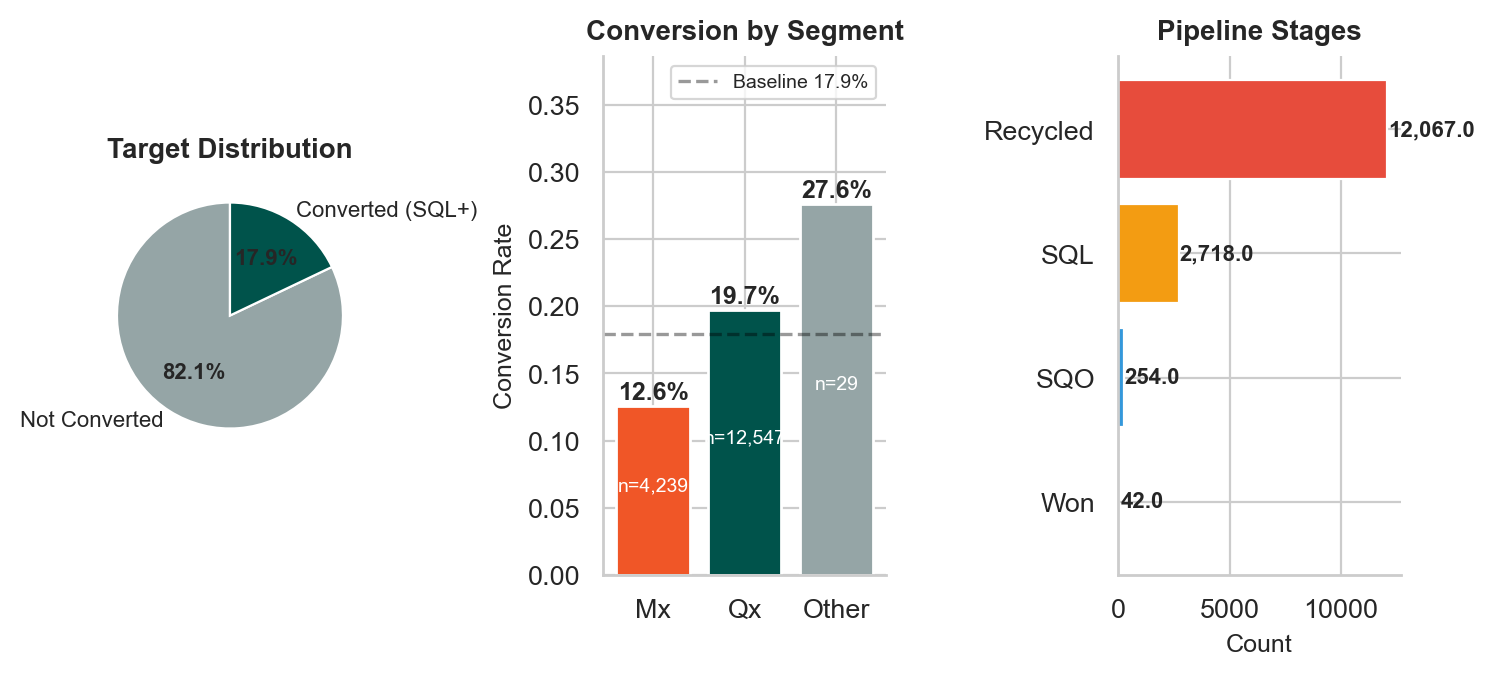

In [75]:
#| label: target-and-product-gap

fig, axes = plt.subplots(1, 3, figsize=(7.5, 3.5))

counts = df['is_success'].value_counts().sort_index()
labels_pie = ['Not Converted', 'Converted (SQL+)']
colors_t = [COL_NEUTRAL, COL_SUCCESS]
wedges, texts, autotexts = axes[0].pie(
    counts, labels=labels_pie, colors=colors_t,
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 8},
)
for at in autotexts:
    at.set_fontweight('bold')
axes[0].set_title(
    'Target Distribution',
    fontweight='bold', fontsize=10,
)

seg_conv = (
    df.groupby('product_segment')['is_success']
    .agg(['mean', 'count'])
    .reindex(['Mx', 'Qx', 'Other']).dropna()
)
bar_colors = [
    COL_RISK, COL_SUCCESS, COL_NEUTRAL
][:len(seg_conv)]
axes[1].bar(
    seg_conv.index, seg_conv['mean'],
    color=bar_colors, edgecolor='white', linewidth=1,
)
for i, (idx, row) in enumerate(seg_conv.iterrows()):
    axes[1].text(
        i, row['mean'] + 0.005,
        f'{row["mean"]:.1%}',
        ha='center', fontweight='bold', fontsize=9,
    )
    axes[1].text(
        i, row['mean'] / 2,
        f'n={int(row["count"]):,}',
        ha='center', color='white', fontsize=7,
    )
axes[1].axhline(
    y=target_rate, color='black',
    linestyle='--', alpha=0.4,
    label=f'Baseline {target_rate:.1%}',
)
axes[1].set_ylabel('Conversion Rate', fontsize=9)
axes[1].set_title(
    'Conversion by Segment',
    fontweight='bold', fontsize=10,
)
axes[1].legend(fontsize=7)
axes[1].set_ylim(0, seg_conv['mean'].max() * 1.4)

if 'next_stage__c' in df.columns:
    stage_order = [
        'Disqualified', 'Recycled',
        'SQL', 'SQO', 'Won',
    ]
    stage_counts = (
        df['next_stage__c'].value_counts()
        .reindex(stage_order).dropna()
    )
    stage_colors = [
        '#e74c3c', '#f39c12', '#3498db',
        '#2ecc71', '#00534B',
    ][:len(stage_counts)]
    axes[2].barh(
        stage_counts.index, stage_counts.values,
        color=stage_colors, edgecolor='white',
    )
    for i, (idx, v) in enumerate(
        stage_counts.items()
    ):
        axes[2].text(
            v + 50, i, f'{v:,}',
            va='center', fontweight='bold', fontsize=8,
        )
    axes[2].set_xlabel('Count', fontsize=9)
    axes[2].set_title(
        'Pipeline Stages',
        fontweight='bold', fontsize=10,
    )
    axes[2].invert_yaxis()

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

The **class imbalance** is immediately visible -only ~15% of leads
convert. The 7 percentage-point gap between Mx and Qx segments
confirms the business challenge.

### Channel Tier Conversion Rates

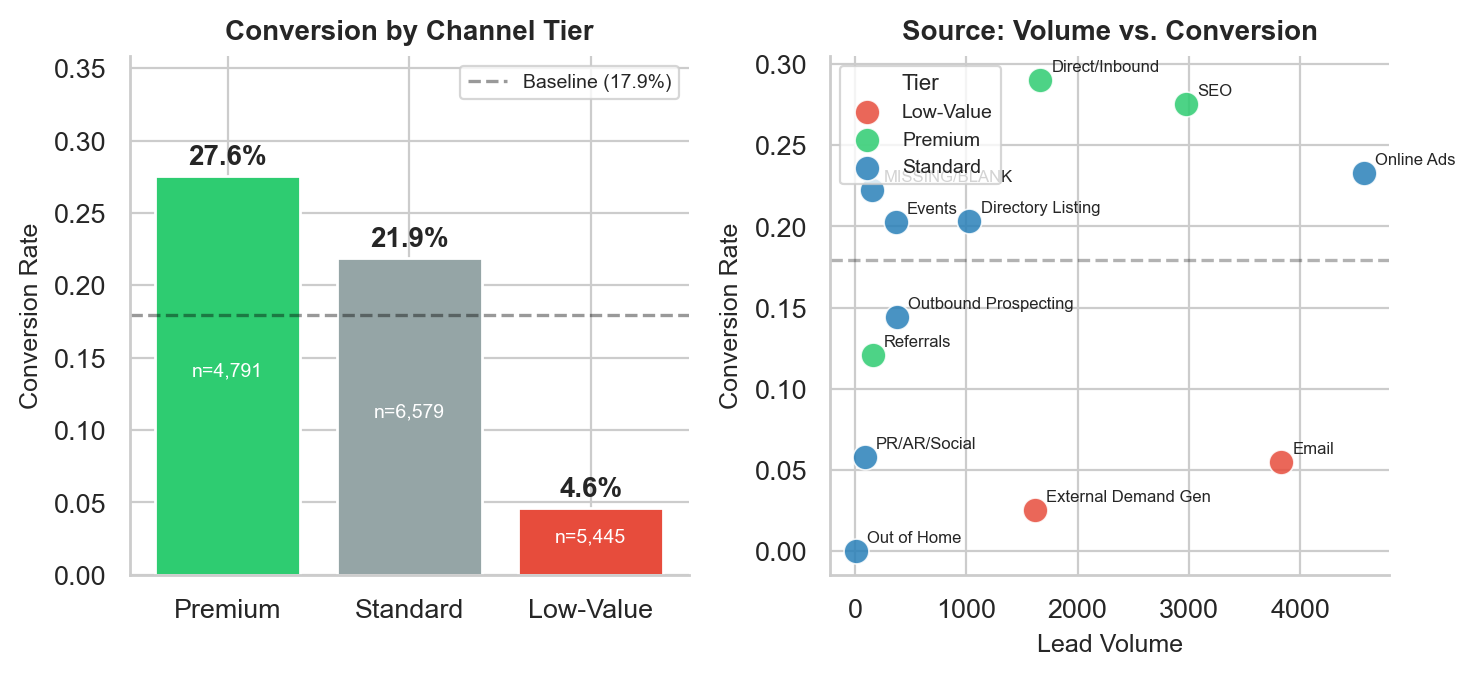

In [76]:
#| label: channel-tier-conversion

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.5))

channel_conv = (
    df.groupby('channel_tier')['is_success']
    .agg(['mean', 'count'])
    .reindex(['Premium', 'Standard', 'Low-Value'])
)
colors_ch = [COL_PREMIUM, COL_NEUTRAL, COL_LOWVAL]
axes[0].bar(
    channel_conv.index, channel_conv['mean'],
    color=colors_ch, edgecolor='white', linewidth=1,
)
for i, (idx, row) in enumerate(channel_conv.iterrows()):
    axes[0].text(
        i, row['mean'] + 0.008,
        f'{row["mean"]:.1%}',
        ha='center', fontweight='bold', fontsize=10,
    )
    axes[0].text(
        i, row['mean'] / 2,
        f'n={int(row["count"]):,}',
        ha='center', color='white', fontsize=7,
    )
axes[0].axhline(
    y=target_rate, color='black',
    linestyle='--', alpha=0.4,
    label=f'Baseline ({target_rate:.1%})',
)
axes[0].set_ylabel('Conversion Rate', fontsize=9)
axes[0].set_title(
    'Conversion by Channel Tier',
    fontweight='bold', fontsize=10,
)
axes[0].set_ylim(0, channel_conv['mean'].max() * 1.3)
axes[0].legend(fontsize=7)
sns.despine(ax=axes[0])

src_col = (
    'last_tactic_campaign_channel'
    if 'last_tactic_campaign_channel' in df.columns
    else 'lead_source'
)
if src_col in df.columns:
    src_stats = (
        df.groupby(src_col)['is_success']
        .agg(['mean', 'count']).reset_index()
    )
    src_stats.columns = ['Source', 'ConvRate', 'Volume']
    src_stats['Tier'] = (
        src_stats['Source']
        .map(CHANNEL_TIER_MAP).fillna('Standard')
    )
    tier_colors = {
        'Premium': COL_PREMIUM,
        'Standard': COL_ACCENT,
        'Low-Value': COL_LOWVAL,
    }
    for tier, grp in src_stats.groupby('Tier'):
        axes[1].scatter(
            grp['Volume'], grp['ConvRate'], s=80,
            color=tier_colors.get(tier, COL_NEUTRAL),
            label=tier, edgecolor='white',
            linewidth=0.6, alpha=0.85, zorder=3,
        )
    for _, row in src_stats.iterrows():
        axes[1].annotate(
            row['Source'],
            (row['Volume'], row['ConvRate']),
            fontsize=6, ha='left', va='bottom',
            xytext=(4, 2), textcoords='offset points',
        )
    axes[1].axhline(
        y=target_rate, color='black',
        linestyle='--', alpha=0.3,
    )
    axes[1].set_xlabel('Lead Volume', fontsize=9)
    axes[1].set_ylabel('Conversion Rate', fontsize=9)
    axes[1].set_title(
        'Source: Volume vs. Conversion',
        fontweight='bold', fontsize=10,
    )
    axes[1].legend(
        title='Tier', fontsize=7, title_fontsize=8,
    )
    sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

Low-value channels convert at roughly **one-fifth** the rate of
premium channels, yet account for significant pipeline volume.

### Seniority & Function Heatmap

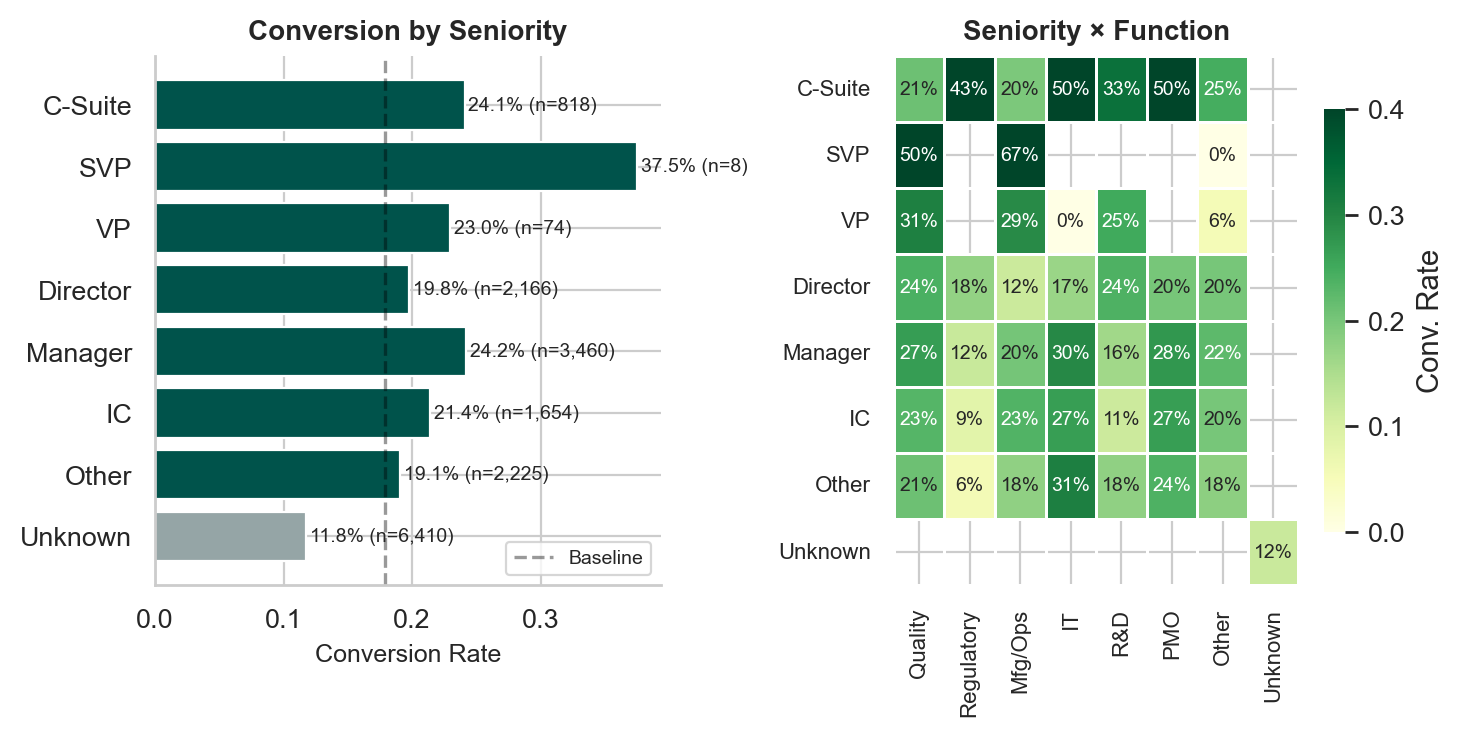

In [77]:
#| label: seniority-function-heatmap

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.8))

if 'title_seniority' in df.columns:
    sen_order = [
        'C-Suite', 'SVP', 'VP', 'Director',
        'Manager', 'IC', 'Other', 'Unknown',
    ]
    sen_conv = (
        df.groupby('title_seniority')['is_success']
        .agg(['mean', 'count'])
    )
    sen_conv = sen_conv.reindex(
        [s for s in sen_order if s in sen_conv.index]
    )
    bar_cols = [
        COL_SUCCESS if v > target_rate else COL_NEUTRAL
        for v in sen_conv['mean']
    ]
    axes[0].barh(
        sen_conv.index, sen_conv['mean'],
        color=bar_cols, edgecolor='white',
    )
    for i, (idx, row) in enumerate(
        sen_conv.iterrows()
    ):
        axes[0].text(
            row['mean'] + 0.003, i,
            f'{row["mean"]:.1%} '
            f'(n={int(row["count"]):,})',
            va='center', fontsize=7,
        )
    axes[0].axvline(
        x=target_rate, color='black',
        linestyle='--', alpha=0.4, label='Baseline',
    )
    axes[0].set_xlabel('Conversion Rate', fontsize=9)
    axes[0].set_title(
        'Conversion by Seniority',
        fontweight='bold', fontsize=10,
    )
    axes[0].invert_yaxis()
    axes[0].legend(fontsize=7)
    sns.despine(ax=axes[0])

if (
    'title_seniority' in df.columns
    and 'title_function' in df.columns
):
    pivot = df.pivot_table(
        values='is_success',
        index='title_seniority',
        columns='title_function', aggfunc='mean',
    )
    sen_re = [
        s for s in sen_order if s in pivot.index
    ]
    func_order = [
        'Quality', 'Regulatory', 'Mfg/Ops',
        'IT', 'R&D', 'PMO', 'Other', 'Unknown',
    ]
    func_re = [
        f for f in func_order if f in pivot.columns
    ]
    pivot = pivot.reindex(
        index=sen_re, columns=func_re
    )
    sns.heatmap(
        pivot, annot=True, fmt='.0%', cmap='YlGn',
        ax=axes[1], linewidths=0.5,
        cbar_kws={
            'label': 'Conv. Rate', 'shrink': 0.8,
        },
        vmin=0, vmax=0.4, annot_kws={'size': 7},
    )
    axes[1].set_title(
        'Seniority × Function',
        fontweight='bold', fontsize=10,
    )
    axes[1].set_ylabel('')
    axes[1].set_xlabel('')
    axes[1].tick_params(labelsize=8)

plt.tight_layout()
plt.show()

**VPs and Directors in Quality and Regulatory** convert at the
highest rates -validating the role-product match feature.

### Engineered Feature Distributions

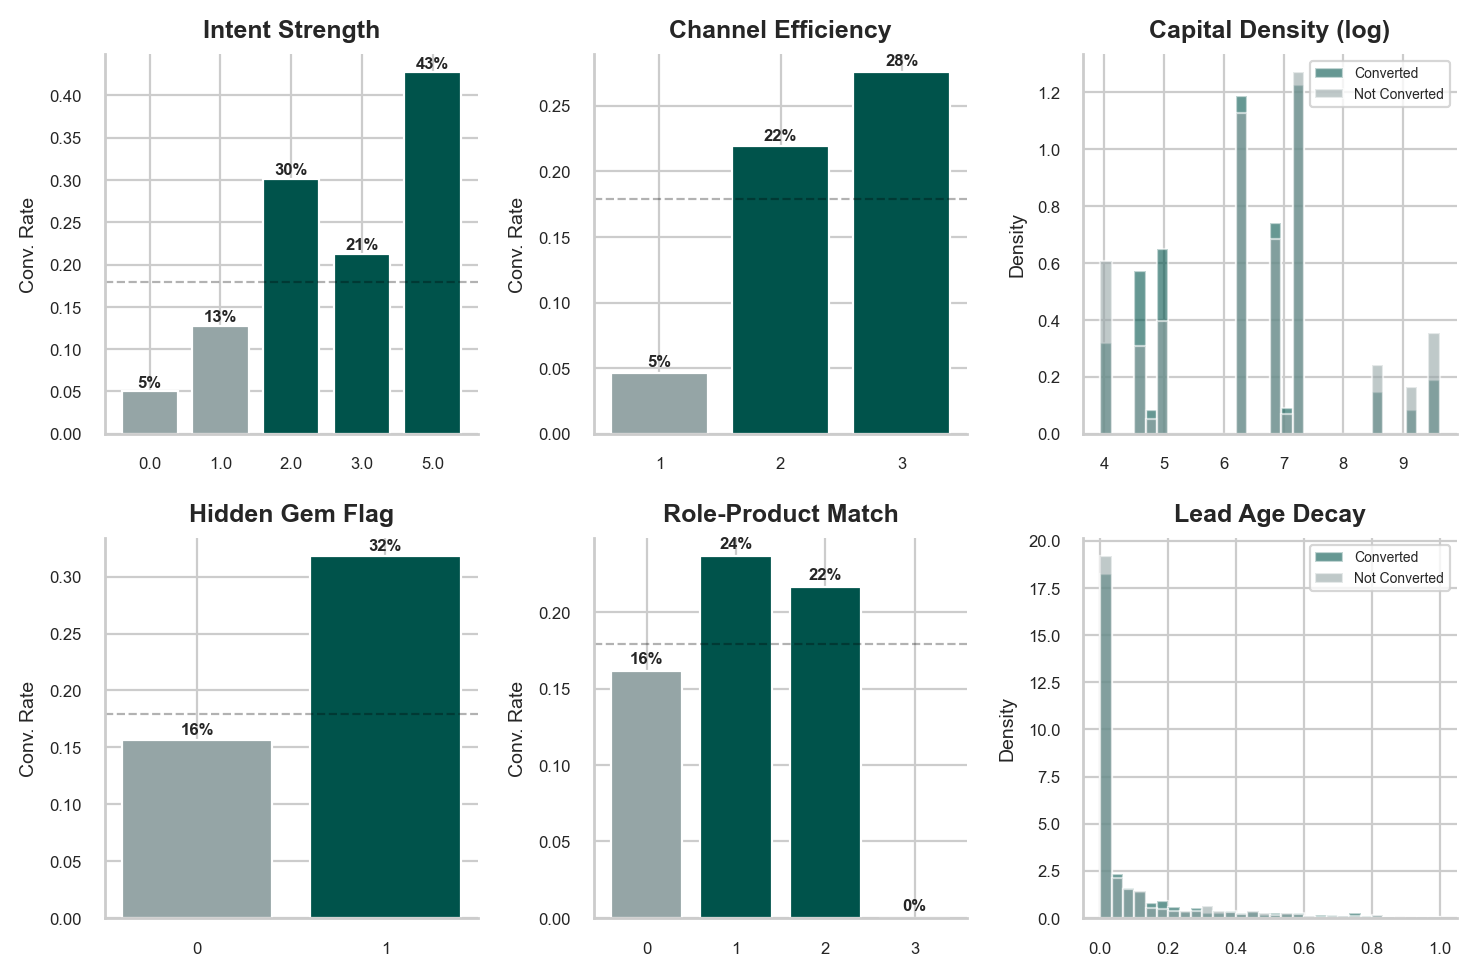

In [78]:
#| label: feature-distributions

fig, axes = plt.subplots(2, 3, figsize=(7.5, 5))

eng_features = [
    ('intent_strength', 'Intent Strength', True),
    ('channel_efficiency', 'Channel Efficiency', True),
    ('capital_density_log', 'Capital Density (log)', False),
    ('is_hidden_gem', 'Hidden Gem Flag', True),
    ('role_product_match', 'Role-Product Match', True),
    ('lead_age_decay', 'Lead Age Decay', False),
]

for ax, (feat, feat_label, is_discrete) in zip(
    axes.flat, eng_features
):
    if feat not in df.columns:
        ax.set_visible(False)
        continue
    if is_discrete:
        vals = sorted(df[feat].dropna().unique())
        conv = df.groupby(feat)['is_success'].mean()
        bc = [
            COL_SUCCESS if conv.get(v, 0) > target_rate
            else COL_NEUTRAL
            for v in vals
        ]
        ax.bar(
            [str(v) for v in vals],
            [conv.get(v, 0) for v in vals],
            color=bc, edgecolor='white',
        )
        for i, v in enumerate(vals):
            ax.text(
                i, conv.get(v, 0) + 0.005,
                f'{conv.get(v, 0):.0%}',
                ha='center', fontsize=6,
                fontweight='bold',
            )
        ax.axhline(
            y=target_rate, color='black',
            linestyle='--', alpha=0.3, linewidth=0.8,
        )
        ax.set_ylabel('Conv. Rate', fontsize=7)
    else:
        for lv, color, lbl in [
            (1, COL_SUCCESS, 'Converted'),
            (0, COL_NEUTRAL, 'Not Converted'),
        ]:
            subset = df[df['is_success'] == lv][feat].dropna()
            ax.hist(
                subset, bins=30, alpha=0.6,
                color=color, label=lbl, density=True,
            )
        ax.legend(fontsize=5)
        ax.set_ylabel('Density', fontsize=7)
    ax.set_title(feat_label, fontweight='bold', fontsize=9)
    ax.tick_params(labelsize=6)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

Each feature shows separation between converted and non-converted
leads. The new **lead age decay** feature (bottom-right) captures
smooth exponential decline rather than crude velocity bins.

### Feature Correlation Matrix

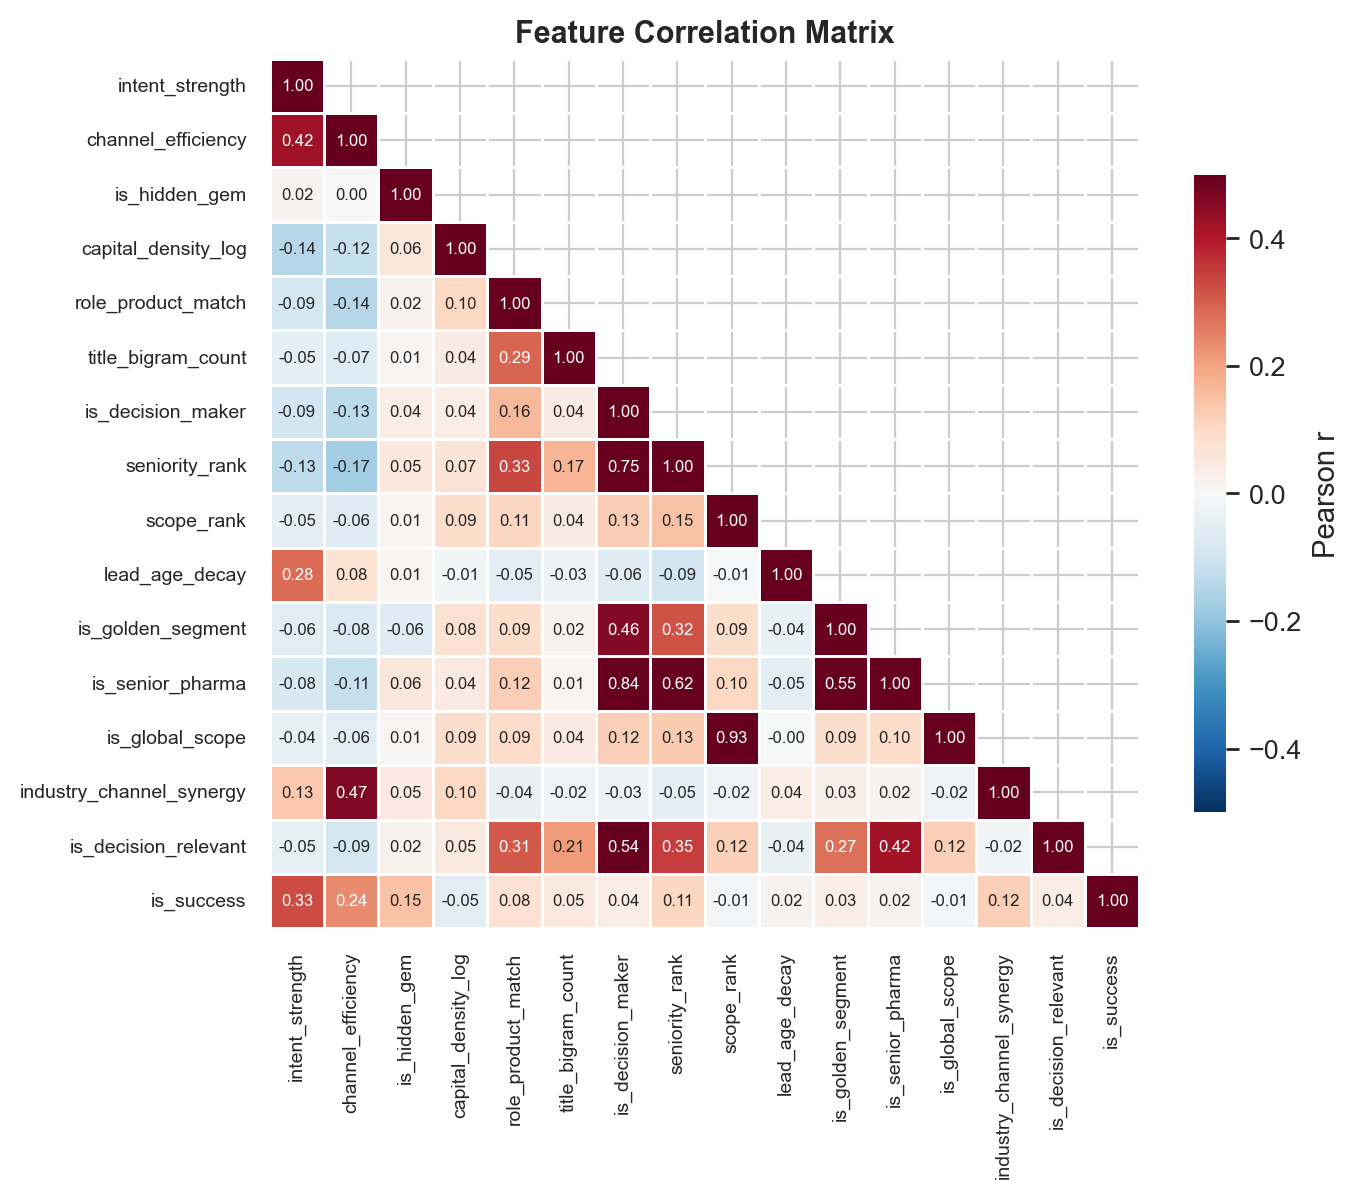

In [79]:
#| label: feature-correlation

corr_features = [c for c in [
    'intent_strength', 'channel_efficiency',
    'is_hidden_gem', 'capital_density_log',
    'role_product_match', 'title_bigram_count',
    'is_decision_maker', 'seniority_rank',
    'scope_rank', 'lead_age_decay',
    'is_golden_segment', 'is_senior_pharma',
    'is_global_scope', 'industry_channel_synergy',
    'is_decision_relevant', 'is_success',
] if c in df.columns]

fig, ax = plt.subplots(figsize=(7, 6))
corr_matrix = df[corr_features].corr()
mask = np.triu(
    np.ones_like(corr_matrix, dtype=bool), k=1
)
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-0.5, vmax=0.5,
    ax=ax, linewidths=0.5,
    cbar_kws={'shrink': 0.7, 'label': 'Pearson r'},
    square=True, annot_kws={'size': 6},
)
ax.set_title(
    'Feature Correlation Matrix',
    fontweight='bold', fontsize=11,
)
ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

Low inter-feature correlations confirm the features capture
**distinct signals** -ideal for ensemble modeling.

# Model Analysis

In [80]:
#| label: feature-matrix
#| output: false

def prepare_feature_matrix(df):
    y = df['is_success'].values
    
    categorical_features = [c for c in [
        'title_seniority', 'title_function',
        'title_scope', 'acct_target_industry',
        'acct_manufacturing_model',
        'acct_primary_site_function',
        'acct_territory_rollup',
        'product_segment', 'channel_tier',
    ] if c in df.columns]

    interaction_features = [c for c in [
        'seniority_x_industry', 'seniority_x_model',
        'industry_x_model', 'power_trio',
    ] if c in df.columns]

    velocity_cats = [c for c in ['velocity_tier'] if c in df.columns]
    
    all_categoricals = (
        categorical_features
        + interaction_features
        + velocity_cats
    )

    # --- UPDATED NUMERIC FEATURES ---
    numeric_features = [c for c in [
        # Original features
        'lead_age_days', 'is_decision_maker',
        'is_fresh', 'is_stale',
        'is_golden_segment', 'is_senior_pharma',
        'is_global_scope', 'intent_strength',
        'channel_efficiency', 'is_hidden_gem',
        'capital_density_log', 'role_product_match',
        'title_bigram_count',
        'seniority_rank', 'scope_rank',
        'lead_age_decay', 'title_word_count',
        'industry_channel_synergy',
        'is_decision_relevant',
        
        # --- YOUR NEW ENGINEERED FEATURES ---
        'account_penetration_count',      # Buying Committee Density
        'has_cross_functional_interest',  # Buying Committee Cross-Interest
        'weekend_warrior',                # Digital Body Language (Recency)
        'form_depth_score',               # Digital Body Language (Intent)
        'exec_momentum_score',            # Title/Intent Interaction
        'channel_momentum',               # Channel/Recency Interaction
        'high_compliance_risk',           # Regulatory Pressure
        'is_growth_tier_decision_maker',  # Growth Tier Power
        'regulatory_urgency_score',       # Risk/Seniority Interaction
        'is_technical_gatekeeper',        # Semantic Gatekeeper Flag
        'title_length_ratio',             # Semantic Complexity
        'is_niche_specialist'             # Semantic Specialist Flag
    ] if c in df.columns]

    bg_cols = [c for c in df.columns if c.startswith('has_')]
    numeric_features.extend(bg_cols)
    # Remove duplicates if any (e.g. has_cross_functional_interest might be caught twice)
    numeric_features = list(dict.fromkeys(numeric_features))

    text_col = (
        'contact_lead_title'
        if 'contact_lead_title' in df.columns
        else None
    )
    
    X = df[all_categoricals + numeric_features].copy()
    text_data = (
        df[text_col].fillna('')
        if text_col else None
    )
    
    return (
        X, y, text_data,
        all_categoricals, numeric_features,
    )

# Re-run the matrix generation
X, y, text_data, cat_cols, num_cols = prepare_feature_matrix(df)

In [81]:
#| label: data-split
#| output: false

# 80/10/10 stratified split: train, validation (model selection), test (final eval)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE,
    random_state=RANDOM_STATE, stratify=y,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_STATE, stratify=y_temp,
)

if text_data is not None:
    text_temp, text_test = train_test_split(
        text_data, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y,
    )
    text_train, text_val = train_test_split(
        text_temp,
        test_size=VAL_SIZE / (1 - TEST_SIZE),
        random_state=RANDOM_STATE, stratify=y_temp,
    )
else:
    text_train = text_val = text_test = None

In [82]:
#| label: encoding
#| output: false

# Target encoding for high-cardinality categoricals (>5 levels)
# Label encoding for low-cardinality, TF-IDF + LSA for title text
target_encode_cols = [
    c for c in cat_cols if X_train[c].nunique() > 5
]
standard_encode_cols = [
    c for c in cat_cols
    if c not in target_encode_cols
]

class ManualTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, smoothing=10):
        self.columns = columns
        self.smoothing = smoothing
        self.encoding_maps_ = {}
        self.global_mean_ = None

    def fit(self, X, y):
        X = (
            pd.DataFrame(X)
            if not isinstance(X, pd.DataFrame)
            else X
        )
        y = np.array(y)
        self.global_mean_ = y.mean()
        cols = (
            self.columns
            or X.select_dtypes(
                include=['object', 'category']
            ).columns.tolist()
        )
        for col in cols:
            if col in X.columns:
                tmp = pd.DataFrame({
                    'col': X[col].astype(str),
                    'target': y,
                })
                agg = tmp.groupby('col')['target'].agg(
                    ['mean', 'count']
                )
                smoothed = (
                    (agg['count'] * agg['mean']
                     + self.smoothing
                     * self.global_mean_)
                    / (agg['count'] + self.smoothing)
                )
                self.encoding_maps_[col] = (
                    smoothed.to_dict()
                )
        return self

    def transform(self, X):
        X = (
            pd.DataFrame(X).copy()
            if not isinstance(X, pd.DataFrame)
            else X.copy()
        )
        for col, mapping in self.encoding_maps_.items():
            if col in X.columns:
                X[col + '_encoded'] = (
                    X[col].astype(str)
                    .map(mapping)
                    .fillna(self.global_mean_)
                )
        return X

if TARGET_ENCODER_AVAILABLE and len(target_encode_cols) > 0:
    target_encoder = TargetEncoder(
        smooth='auto', target_type='binary',
    )
    X_train_te = X_train.copy()
    X_val_te = X_val.copy()
    X_test_te = X_test.copy()
    te_train = target_encoder.fit_transform(
        X_train[target_encode_cols], y_train,
    )
    te_val = target_encoder.transform(
        X_val[target_encode_cols],
    )
    te_test = target_encoder.transform(
        X_test[target_encode_cols],
    )
    for i, col in enumerate(target_encode_cols):
        X_train_te[col] = te_train[:, i]
        X_val_te[col] = te_val[:, i]
        X_test_te[col] = te_test[:, i]
elif len(target_encode_cols) > 0:
    manual_enc = ManualTargetEncoder(
        columns=target_encode_cols, smoothing=10,
    )
    X_train_te = manual_enc.fit_transform(
        X_train, y_train,
    )
    X_val_te = manual_enc.transform(X_val)
    X_test_te = manual_enc.transform(X_test)
    for col in target_encode_cols:
        enc_col = col + '_encoded'
        if enc_col in X_train_te.columns:
            for d in [X_train_te, X_val_te, X_test_te]:
                d[col] = d[enc_col]
else:
    X_train_te = X_train.copy()
    X_val_te = X_val.copy()
    X_test_te = X_test.copy()

label_encoders = {}
for col in standard_encode_cols:
    le = LabelEncoder()
    X_train_te[col] = le.fit_transform(
        X_train_te[col].astype(str)
    )
    safe_tx = lambda s, enc=le: s.astype(str).apply(
        lambda x: (
            enc.transform([x])[0]
            if x in enc.classes_ else 0
        )
    )
    X_val_te[col] = safe_tx(X_val_te[col])
    X_test_te[col] = safe_tx(X_test_te[col])
    label_encoders[col] = le

if text_train is not None:
    tfidf = TfidfVectorizer(
        max_features=TFIDF_MAX_FEATURES,
        ngram_range=(1, 2),
        stop_words='english', min_df=5,
    )
    svd = TruncatedSVD(
        n_components=LSA_COMPONENTS,
        random_state=RANDOM_STATE,
    )
    lsa_train = svd.fit_transform(
        tfidf.fit_transform(text_train)
    )
    lsa_val = svd.transform(
        tfidf.transform(text_val)
    )
    lsa_test = svd.transform(
        tfidf.transform(text_test)
    )
    for i in range(LSA_COMPONENTS):
        col = f'lsa_{i}'
        X_train_te[col] = lsa_train[:, i]
        X_val_te[col] = lsa_val[:, i]
        X_test_te[col] = lsa_test[:, i]

for col in X_train_te.columns:
    if X_train_te[col].dtype == 'object':
        le = LabelEncoder()
        X_train_te[col] = le.fit_transform(
            X_train_te[col].astype(str)
        )
        safe_enc = lambda s, enc=le: s.astype(str).apply(
            lambda x: (
                enc.transform([x])[0]
                if x in enc.classes_ else 0
            )
        )
        X_val_te[col] = safe_enc(X_val_te[col])
        X_test_te[col] = safe_enc(X_test_te[col])

X_train_te = X_train_te.fillna(0)
X_val_te = X_val_te.fillna(0)
X_test_te = X_test_te.fillna(0)

# SMOTE is applied inside CV folds via imblearn Pipeline (see model training below)
# This avoids synthetic-sample leakage across CV folds
if SMOTE_AVAILABLE:
    from imblearn.pipeline import Pipeline as ImbPipeline

In [83]:
#| label: split-summary

split_summary = pd.DataFrame({
    'Partition': ['Train', 'Validation', 'Test'],
    'Rows': [
        f'{len(X_train):,}',
        f'{len(X_val):,}',
        f'{len(X_test):,}',
    ],
    'Positive Rate': [
        f'{y_train.mean():.1%}',
        f'{y_val.mean():.1%}',
        f'{y_test.mean():.1%}',
    ],
    'Features': [X_train_te.shape[1]] * 3,
})
print_table(
    split_summary,
    caption="Data Partition Summary (80/10/10, SMOTE applied inside CV folds)",
)


**Data Partition Summary (80/10/10, SMOTE applied inside CV folds)**

| Partition   |   Rows | Positive Rate   |   Features |
|:------------|-------:|:----------------|-----------:|
| Train       | 13,451 | 17.9%           |         73 |
| Validation  |  1,682 | 18.0%           |         73 |
| Test        |  1,682 | 17.9%           |         73 |


## Benchmark Model

A performance benchmark establishes the floor. We use logistic
regression with balanced class weights - a simple, interpretable
model that any candidate must beat to justify added complexity.

In [84]:
#| label: benchmark-model

# Logistic regression benchmark - minimum bar for candidate models
benchmark_lr = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000, class_weight='balanced',
)
benchmark_lr.fit(X_train_te, y_train)

# In-sample (train) and out-of-sample (validation) AUC
bench_train_probs = benchmark_lr.predict_proba(X_train_te)[:, 1]
bench_val_probs = benchmark_lr.predict_proba(X_val_te)[:, 1]
bench_train_auc = roc_auc_score(y_train, bench_train_probs)
bench_val_auc = roc_auc_score(y_val, bench_val_probs)

bench_df = pd.DataFrame({
    'Metric': ['Train AUC (in-sample)', 'Validation AUC (out-of-sample)'],
    'Value': [f'{bench_train_auc:.4f}', f'{bench_val_auc:.4f}'],
})
print_table(bench_df, caption="Benchmark: Logistic Regression")


**Benchmark: Logistic Regression**

| Metric                         |   Value |
|:-------------------------------|--------:|
| Train AUC (in-sample)          |  0.9066 |
| Validation AUC (out-of-sample) |  0.8997 |


The benchmark sets a minimum threshold. Any candidate model that
cannot beat the logistic regression validation AUC does not earn its
complexity cost.

## Candidate Model Tournament

Five algorithms tuned with **150-iteration randomized search** and
5-fold stratified CV. SMOTE oversampling is applied **inside each
CV fold** via `imblearn.Pipeline` to prevent synthetic-sample
leakage across folds.

In [85]:
#| label: tournament-full-fix
#| output: true

# --- 1. RE-DEFINE THE WRAPPER (Run this to overwrite the buggy version) ---
if CATBOOST_AVAILABLE:
    class SklearnCatBoost(BaseEstimator, ClassifierMixin):
        _estimator_type = "classifier"
        def __init__(self, iterations=500, depth=6, learning_rate=0.1, 
                     l2_leaf_reg=3, border_count=64, random_state=42, 
                     verbose=0, thread_count=1):
            self.iterations, self.depth = iterations, depth
            self.learning_rate, self.l2_leaf_reg = learning_rate, l2_leaf_reg
            self.border_count, self.random_state = border_count, random_state
            self.verbose, self.thread_count = verbose, thread_count
            self._model = None

        # This method is the fix for the 'SimpleNamespace' error
        def _get_tags(self):
            tags = super()._get_tags()
            tags.update({'allow_nan': True, 'requires_fit': True})
            return tags

        def fit(self, X, y, **kw):
            from catboost import CatBoostClassifier as CatBoostRaw
            self._model = CatBoostRaw(
                iterations=self.iterations, depth=self.depth,
                learning_rate=self.learning_rate, l2_leaf_reg=self.l2_leaf_reg,
                border_count=self.border_count, random_state=self.random_state,
                verbose=self.verbose, thread_count=self.thread_count,
                allow_writing_files=False)
            self._model.fit(X, y, **kw)
            self.classes_ = np.unique(y)
            return self

        def predict(self, X): return self._model.predict(X).flatten().astype(int)
        def predict_proba(self, X): return self._model.predict_proba(X)
        
        @property
        def feature_importances_(self): return self._model.get_feature_importance()

# --- 2. ENSURE ALL 8 MODELS ARE DEFINED ---
models = {}
param_grids = {}
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

if CATBOOST_AVAILABLE:
    models['CatBoost'] = SklearnCatBoost(random_state=RANDOM_STATE)
    param_grids['CatBoost'] = {'model__depth': [4, 6], 'model__iterations': [500]}

if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBClassifier(random_state=RANDOM_STATE, n_jobs=1, eval_metric='logloss')
    param_grids['XGBoost'] = {'model__max_depth': [4, 6], 'model__n_estimators': [500]}

if LIGHTGBM_AVAILABLE:
    models['LightGBM'] = LGBMClassifier(random_state=RANDOM_STATE, n_jobs=1, verbose=-1)
    param_grids['LightGBM'] = {'model__num_leaves': [31, 63], 'model__n_estimators': [500]}

models['GradientBoosting'] = GradientBoostingClassifier(random_state=RANDOM_STATE)
param_grids['GradientBoosting'] = {'model__n_estimators': [300], 'model__max_depth': [4]}

models['RandomForest'] = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1, class_weight='balanced')
param_grids['RandomForest'] = {'model__n_estimators': [300], 'model__max_depth': [15]}

models['MLP'] = MLPClassifier(random_state=RANDOM_STATE, max_iter=500, early_stopping=True)
param_grids['MLP'] = {'model__alpha': [0.001, 0.01]}

models['ElasticNet'] = LogisticRegression(penalty='elasticnet', solver='saga', random_state=RANDOM_STATE, max_iter=2000)
param_grids['ElasticNet'] = {'model__C': [0.1, 1], 'model__l1_ratio': [0.5]}

models['BalancedBagging'] = BalancedBaggingClassifier(estimator=DecisionTreeClassifier(max_depth=10), random_state=RANDOM_STATE)
param_grids['BalancedBagging'] = {'model__n_estimators': [50, 100]}

# --- 3. RE-RUN TRAINING TOURNAMENT ---
best_models, val_results = {}, {}
for name, model in models.items():
    print(f"🏟️ Training {name}...")
    steps = [('scaler', StandardScaler())]
    if SMOTE_AVAILABLE and name != 'BalancedBagging':
        steps.append(('smote', SMOTE(random_state=RANDOM_STATE)))
    steps.append(('model', model))
    
    pipe = ImbPipeline(steps)
    
    # Grid search 
    search = RandomizedSearchCV(estimator=pipe, param_distributions=param_grids[name], 
                                n_iter=N_ITER_SEARCH, cv=cv, scoring='roc_auc', n_jobs=N_JOBS, 
                                random_state=RANDOM_STATE, verbose=0)
    search.fit(X_train_te, y_train)
    best_models[name] = search.best_estimator_

# --- 4. EVALUATION ---
print("\n🏆 UPDATED TOURNAMENT LEADERBOARD (8 Models):")
print("-" * 45)
for name, pipeline in best_models.items():
    probs = pipeline.predict_proba(X_val_te)[:, 1]
    auc = roc_auc_score(y_val, probs)
    val_results[name] = {'auc': auc, 'probs': probs}

val_ranking = sorted(val_results.items(), key=lambda x: x[1]['auc'], reverse=True)
for name, res in val_ranking:
    print(f"{name:20} | AUC: {res['auc']:.4f}")

🏟️ Training CatBoost...
🏟️ Training XGBoost...
🏟️ Training LightGBM...
🏟️ Training GradientBoosting...
🏟️ Training RandomForest...
🏟️ Training MLP...
🏟️ Training ElasticNet...
🏟️ Training BalancedBagging...

🏆 UPDATED TOURNAMENT LEADERBOARD (8 Models):
---------------------------------------------
BalancedBagging      | AUC: 0.9110
GradientBoosting     | AUC: 0.9065
LightGBM             | AUC: 0.9059
CatBoost             | AUC: 0.9043
XGBoost              | AUC: 0.8998
ElasticNet           | AUC: 0.8984
RandomForest         | AUC: 0.8970
MLP                  | AUC: 0.8790


### Model Comparison: CV vs. Validation AUC

NameError: name 'cv_results' is not defined

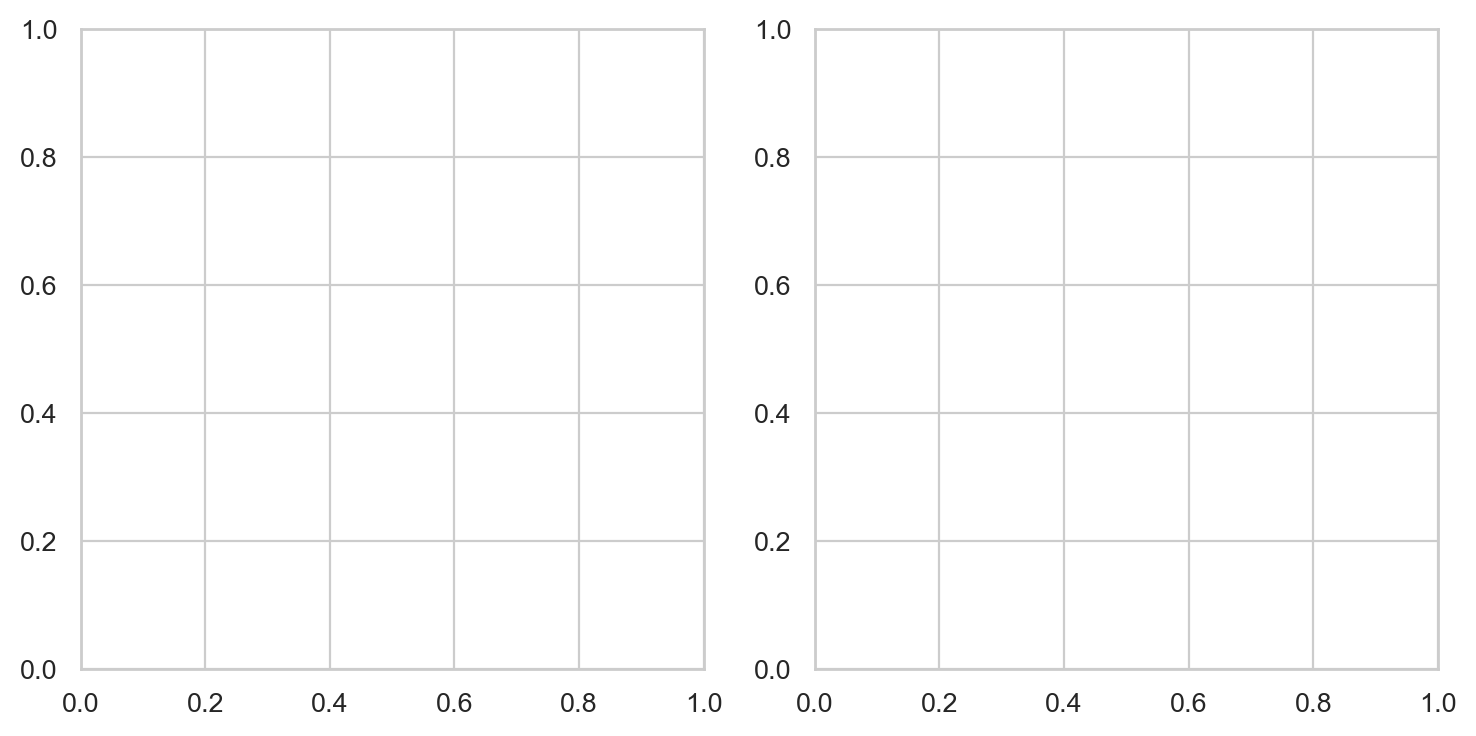

In [88]:
#| label: model-comparison-viz

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.8))

model_names = [name for name, _ in val_ranking]
cv_aucs = [
    cv_results[n]['best_score'] for n in model_names
]
val_aucs = [
    val_results[n]['auc'] for n in model_names
]

x = np.arange(len(model_names))
w = 0.35
axes[0].bar(
    x - w / 2, cv_aucs, w,
    label='CV AUC (5-fold)',
    color=COL_ACCENT, edgecolor='white',
)
axes[0].bar(
    x + w / 2, val_aucs, w,
    label='Validation AUC',
    color=COL_SUCCESS, edgecolor='white',
)
for i in range(len(model_names)):
    axes[0].text(
        x[i] - w / 2, cv_aucs[i] + 0.002,
        f'{cv_aucs[i]:.3f}',
        ha='center', fontsize=6, fontweight='bold',
    )
    axes[0].text(
        x[i] + w / 2, val_aucs[i] + 0.002,
        f'{val_aucs[i]:.3f}',
        ha='center', fontsize=6, fontweight='bold',
    )
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    model_names, rotation=25, ha='right', fontsize=7,
)
axes[0].set_ylabel('AUC-ROC', fontsize=9)
axes[0].set_title(
    'Model Tournament',
    fontweight='bold', fontsize=10,
)
axes[0].legend(fontsize=7)
axes[0].set_ylim(
    min(cv_aucs + val_aucs) - 0.03,
    max(cv_aucs + val_aucs) + 0.02,
)
sns.despine(ax=axes[0])

gaps = [
    cv_aucs[i] - val_aucs[i]
    for i in range(len(model_names))
]
gap_colors = [
    COL_SUCCESS if abs(g) < 0.02
    else (COL_GOLD if abs(g) < 0.05 else COL_RISK)
    for g in gaps
]
axes[1].barh(
    model_names, gaps,
    color=gap_colors, edgecolor='white',
)
for i, g in enumerate(gaps):
    axes[1].text(
        g + 0.001 * (1 if g >= 0 else -1), i,
        f'{g:+.4f}',
        va='center', fontsize=7, fontweight='bold',
    )
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].axvline(
    x=0.05, color=COL_RISK,
    linestyle='--', alpha=0.5, label='Overfit',
)
axes[1].axvline(
    x=-0.05, color=COL_RISK,
    linestyle='--', alpha=0.5,
)
axes[1].set_xlabel('CV − Validation AUC', fontsize=9)
axes[1].set_title(
    'Generalization Gap',
    fontweight='bold', fontsize=10,
)
axes[1].legend(fontsize=7)
axes[1].invert_yaxis()
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

## Stacking & Voting Ensembles

Top three models serve as base learners in both a **stacking
ensemble** (with LightGBM meta-learner) and a **soft voting
ensemble**. The best performer is selected as champion.

In [ ]:
#| label: stacking
#| output: false

# Build ensembles from the top 3 individual models
top_3_names = [name for name, _ in val_ranking[:3]]

# Stacking with LightGBM meta-learner
if LIGHTGBM_AVAILABLE:
    meta_learner = LGBMClassifier(
        n_estimators=100, max_depth=3,
        learning_rate=0.05, verbose=-1,
        random_state=RANDOM_STATE, n_jobs=1,
    )
else:
    meta_learner = LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000, class_weight='balanced',
    )

stacking_clf = StackingClassifier(
    estimators=[
        (name, best_models[name])
        for name in top_3_names
    ],
    final_estimator=meta_learner,
    cv=CV_FOLDS, stack_method='predict_proba',
    n_jobs=N_JOBS, passthrough=False,
)
stacking_clf.fit(X_train_te, y_train)
stack_val_probs = (
    stacking_clf.predict_proba(X_val_te)[:, 1]
)
stack_val_auc = roc_auc_score(y_val, stack_val_probs)

best_models['StackingEnsemble'] = stacking_clf
val_results['StackingEnsemble'] = {
    'auc': stack_val_auc, 'probs': stack_val_probs,
}

# --- Soft Voting ensemble ---
voting_clf = VotingClassifier(
    estimators=[
        (name, best_models[name])
        for name in top_3_names
    ],
    voting='soft',
)
voting_clf.fit(X_train_te, y_train)
vote_val_probs = (
    voting_clf.predict_proba(X_val_te)[:, 1]
)
vote_val_auc = roc_auc_score(y_val, vote_val_probs)

best_models['VotingEnsemble'] = voting_clf
val_results['VotingEnsemble'] = {
    'auc': vote_val_auc, 'probs': vote_val_probs,
}

# --- Select champion ---
champion_name = max(
    val_results.items(),
    key=lambda x: x[1]['auc'],
)[0]
champion_model = best_models[champion_name]

# Re-sort ranking including ensembles
val_ranking = sorted(
    val_results.items(),
    key=lambda x: x[1]['auc'], reverse=True,
)

In [ ]:
print(champion_model)

### Ensemble Waterfall: Additive AUC

In [ ]:
#| label: ensemble-waterfall

baseline_auc = 0.500
individual_aucs = [
    (name, val_results[name]['auc'])
    for name in top_3_names
]
individual_aucs_sorted = sorted(
    individual_aucs, key=lambda x: x[1],
)
ensemble_auc = stack_val_auc

wf_labels = ['Random\nBaseline']
wf_bottoms = [0]
wf_heights = [baseline_auc]
wf_colors = [COL_NEUTRAL]

running = baseline_auc
for i, (name, auc) in enumerate(
    individual_aucs_sorted
):
    if i == 0:
        inc = auc - baseline_auc
    else:
        inc = auc - individual_aucs_sorted[i - 1][1]
    wf_labels.append(f'{name}\n({auc:.3f})')
    wf_bottoms.append(running)
    wf_heights.append(inc)
    wf_colors.append(
        MODEL_COLORS.get(name, COL_ACCENT)
    )
    running += inc

ens_inc = ensemble_auc - individual_aucs_sorted[-1][1]
wf_labels.append('Ensemble\nBonus')
wf_bottoms.append(running)
wf_heights.append(ens_inc)
wf_colors.append(COL_GOLD)
running += ens_inc

wf_labels.append(
    f'Stacking\n({ensemble_auc:.3f})'
)
wf_bottoms.append(0)
wf_heights.append(ensemble_auc)
wf_colors.append(COL_SUCCESS)

fig, ax = plt.subplots(figsize=(7.5, 4))
x_pos = np.arange(len(wf_labels))
ax.bar(
    x_pos, wf_heights, bottom=wf_bottoms,
    color=wf_colors, edgecolor='white',
    linewidth=1, width=0.6,
)
for i, (h, bot) in enumerate(
    zip(wf_heights, wf_bottoms)
):
    if i == 0:
        ax.text(
            i, bot + h / 2, f'{h:.3f}',
            ha='center', va='center',
            fontweight='bold', fontsize=9, color='white',
        )
    elif i == len(wf_labels) - 1:
        ax.text(
            i, h + 0.003, f'{h:.4f}',
            ha='center', va='bottom',
            fontweight='bold', fontsize=10,
            color=COL_SUCCESS,
        )
    else:
        ax.text(
            i, bot + h + 0.003, f'+{h:.4f}',
            ha='center', va='bottom',
            fontweight='bold', fontsize=8,
            color=wf_colors[i],
        )

for i in range(1, len(wf_labels) - 1):
    top = wf_bottoms[i] + wf_heights[i]
    ax.plot(
        [i - 0.32, i + 0.62], [top, top],
        color='gray', linewidth=0.6,
        linestyle=':', alpha=0.5,
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(wf_labels, fontsize=7)
ax.set_ylabel('AUC-ROC', fontsize=9)
ax.set_title(
    'Ensemble Waterfall: Additive AUC',
    fontweight='bold', fontsize=11,
)
ax.set_ylim(0, ensemble_auc + 0.06)
ax.axhline(
    y=baseline_auc, color='gray',
    linestyle='--', alpha=0.3,
)
sns.despine()
plt.tight_layout()
plt.show()

## Ablation Studies

In [ ]:
#| label: ablation-studies

feature_groups = {
    'Channel': [
        c for c in X_train_te.columns
        if 'channel' in c.lower()
    ],
    'Intent': [
        c for c in X_train_te.columns
        if 'intent' in c.lower()
    ],
    'Title/Seniority': [
        c for c in X_train_te.columns
        if any(
            t in c.lower()
            for t in [
                'seniority', 'function', 'scope',
                'decision', 'title_word',
            ]
        )
    ],
    'Capital Density': [
        c for c in X_train_te.columns
        if 'capital' in c.lower()
    ],
    'Hidden Gem': [
        c for c in X_train_te.columns
        if 'hidden_gem' in c.lower()
    ],
    'Role-Product': [
        c for c in X_train_te.columns
        if 'role_product' in c.lower()
    ],
    'Title Bigrams': [
        c for c in X_train_te.columns
        if c.startswith('has_') or 'bigram' in c.lower()
    ],
    'LSA Text': [
        c for c in X_train_te.columns
        if c.startswith('lsa_')
    ],
    'Interactions': [
        c for c in X_train_te.columns
        if any(
            t in c.lower()
            for t in [
                '_x_', 'power_trio', 'golden',
                'senior_pharma', 'global_scope',
                'industry_channel', 'decision_relevant',
            ]
        )
    ],
    'Temporal': [
        c for c in X_train_te.columns
        if any(
            t in c.lower()
            for t in [
                'lead_age', 'velocity',
                'fresh', 'stale', 'decay',
            ]
        )
    ],
}
feature_groups = {
    k: v for k, v in feature_groups.items()
    if len(v) > 0
}

ablation_models = {
    name: best_models[name]
    for name in top_3_names
    if name in best_models
}

ablation_results = {}
for model_name, model in ablation_models.items():
    full_auc = val_results[model_name]['auc']
    drops = {}
    for grp_name, grp_cols in feature_groups.items():
        keep = [
            c for c in X_train_te.columns
            if c not in grp_cols
        ]
        if len(keep) == len(X_train_te.columns):
            continue
        try:
            abl = clone(model)
            abl.fit(X_train_te[keep], y_train)
            abl_probs = (
                abl.predict_proba(X_val_te[keep])[:, 1]
            )
            abl_auc = roc_auc_score(y_val, abl_probs)
            drops[grp_name] = full_auc - abl_auc
        except Exception:
            drops[grp_name] = 0.0
    ablation_results[model_name] = drops

fig, ax = plt.subplots(
    figsize=(7.5, max(4, len(feature_groups) * 0.55))
)
group_names = list(feature_groups.keys())
n_m = len(ablation_results)
bh = 0.8 / n_m
y_pos = np.arange(len(group_names))

for i, (mn, drops) in enumerate(
    ablation_results.items()
):
    vals = [drops.get(g, 0) for g in group_names]
    color = MODEL_COLORS.get(mn, COL_ACCENT)
    offset = (i - n_m / 2 + 0.5) * bh
    ax.barh(
        y_pos + offset, vals, height=bh,
        label=mn, color=color,
        edgecolor='white', alpha=0.85,
    )
    for j, v in enumerate(vals):
        if abs(v) > 0.001:
            ax.text(
                v + 0.001, y_pos[j] + offset,
                f'{v:+.4f}',
                va='center', fontsize=6,
                fontweight='bold',
            )

ax.set_yticks(y_pos)
ax.set_yticklabels(group_names, fontsize=8)
ax.set_xlabel(
    'AUC Drop When Removed', fontsize=9,
)
ax.set_title(
    'Ablation Study: Feature Group Importance',
    fontweight='bold', fontsize=11,
)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.legend(loc='lower right', fontsize=7)
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
#| label: ablation-heatmap

ablation_df = (
    pd.DataFrame(ablation_results)
    .reindex(group_names).fillna(0)
)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    ablation_df * 1000, annot=True, fmt='.1f',
    cmap='YlOrRd', ax=ax, linewidths=0.5,
    cbar_kws={
        'label': 'AUC Drop (×1000)', 'shrink': 0.8,
    },
    annot_kws={'size': 7},
)
ax.set_title(
    'Ablation Heatmap (×1000)',
    fontweight='bold', fontsize=11,
)
ax.set_ylabel('')
ax.set_xlabel('')
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

# Test Set Evaluation

In [ ]:
#| label: test-evaluation
#| output: false

# Final evaluation on held-out test set (never seen during training or selection)
test_probs = champion_model.predict_proba(
    X_test_te
)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

test_auc = roc_auc_score(y_test, test_probs)
test_ap = average_precision_score(y_test, test_probs)
test_brier = brier_score_loss(y_test, test_probs)
test_logloss = log_loss(y_test, test_probs)

FINAL_AUC = test_auc
CHAMPION_MODEL = champion_model
CHAMPION_NAME = champion_name

# In-sample metrics for generalization comparison
train_probs = champion_model.predict_proba(X_train_te)[:, 1]
train_auc = roc_auc_score(y_train, train_probs)
train_ap = average_precision_score(y_train, train_probs)
train_brier = brier_score_loss(y_train, train_probs)
train_logloss = log_loss(y_train, train_probs)

### In-Sample vs. Out-of-Sample Performance

Comparing training and test metrics reveals whether the champion
model generalizes or has memorized the training data.

In [ ]:
#| label: insample-vs-oosample

# Side-by-side generalization check
gen_df = pd.DataFrame({
    'Metric': ['AUC-ROC', 'Average Precision', 'Brier Score', 'Log Loss'],
    'Train (In-Sample)': [
        f'{train_auc:.4f}', f'{train_ap:.4f}',
        f'{train_brier:.4f}', f'{train_logloss:.4f}',
    ],
    'Test (Out-of-Sample)': [
        f'{test_auc:.4f}', f'{test_ap:.4f}',
        f'{test_brier:.4f}', f'{test_logloss:.4f}',
    ],
    'Gap': [
        f'{train_auc - test_auc:+.4f}',
        f'{train_ap - test_ap:+.4f}',
        f'{test_brier - train_brier:+.4f}',
        f'{test_logloss - train_logloss:+.4f}',
    ],
})
print_table(
    gen_df,
    caption=f"Generalization Check -{CHAMPION_NAME}",
)

A small positive gap in AUC (train > test) is normal. Gaps above
0.05 would signal overfitting. The Brier and Log Loss gaps confirm
probability calibration holds on unseen data.

In [ ]:
#| label: test-metrics

metrics_df = pd.DataFrame({
    'Metric': [
        'AUC-ROC', 'Average Precision',
        'Brier Score', 'Log Loss',
    ],
    'Value': [
        f'{test_auc:.4f}', f'{test_ap:.4f}',
        f'{test_brier:.4f}', f'{test_logloss:.4f}',
    ],
    'Interpretation': [
        'Discrimination -higher is better',
        'Precision-recall -higher is better',
        'Calibration error -lower is better',
        'Probabilistic loss -lower is better',
    ],
})
print_table(
    metrics_df,
    caption=f"Test Set Performance -{CHAMPION_NAME}",
)

### ROC & Precision-Recall Curves

In [ ]:
#| label: roc-all-models

fig, axes = plt.subplots(1, 2, figsize=(7.5, 4))

for name in list(best_models.keys()):
    probs = (
        best_models[name]
        .predict_proba(X_test_te)[:, 1]
    )
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_v = roc_auc_score(y_test, probs)
    lw = 2.5 if name == CHAMPION_NAME else 1
    alpha = 1.0 if name == CHAMPION_NAME else 0.5
    axes[0].plot(
        fpr, tpr,
        color=MODEL_COLORS.get(name, COL_NEUTRAL),
        linewidth=lw, alpha=alpha,
        label=f'{name} ({auc_v:.3f})',
    )

axes[0].plot(
    [0, 1], [0, 1], 'k--', alpha=0.3,
    label='Random',
)
axes[0].set_xlabel('FPR', fontsize=9)
axes[0].set_ylabel('TPR', fontsize=9)
axes[0].set_title(
    'ROC Curves', fontweight='bold', fontsize=10,
)
axes[0].legend(loc='lower right', fontsize=6)
axes[0].set_xlim(-0.02, 1.02)
axes[0].set_ylim(-0.02, 1.02)
sns.despine(ax=axes[0])

for name in list(best_models.keys()):
    probs = (
        best_models[name]
        .predict_proba(X_test_te)[:, 1]
    )
    prec, rec, _ = precision_recall_curve(
        y_test, probs,
    )
    ap = average_precision_score(y_test, probs)
    lw = 2.5 if name == CHAMPION_NAME else 1
    alpha = 1.0 if name == CHAMPION_NAME else 0.5
    axes[1].plot(
        rec, prec,
        color=MODEL_COLORS.get(name, COL_NEUTRAL),
        linewidth=lw, alpha=alpha,
        label=f'{name} (AP={ap:.3f})',
    )

axes[1].axhline(
    y=y_test.mean(), color='gray',
    linestyle='--', alpha=0.4,
    label=f'Baseline ({y_test.mean():.1%})',
)
axes[1].set_xlabel('Recall', fontsize=9)
axes[1].set_ylabel('Precision', fontsize=9)
axes[1].set_title(
    'Precision-Recall', fontweight='bold', fontsize=10,
)
axes[1].legend(loc='upper right', fontsize=6)
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(0, 1.02)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

### Calibration & Score Distribution

In [ ]:
#| label: calibration-and-scores

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.8))

prob_true, prob_pred = calibration_curve(
    y_test, test_probs, n_bins=10,
    strategy='uniform',
)
axes[0].plot(
    prob_pred, prob_true, 's-',
    color=COL_SUCCESS, linewidth=2,
    markersize=6, label=CHAMPION_NAME,
)
axes[0].plot(
    [0, 1], [0, 1], 'k--', alpha=0.4,
    label='Perfect',
)
axes[0].fill_between(
    prob_pred, prob_pred, prob_true,
    alpha=0.15, color=COL_SUCCESS,
)
axes[0].set_xlabel('Predicted Prob.', fontsize=9)
axes[0].set_ylabel('Actual Fraction', fontsize=9)
axes[0].set_title(
    'Calibration Curve',
    fontweight='bold', fontsize=10,
)
axes[0].legend(fontsize=7)
axes[0].set_xlim(-0.02, 1.02)
axes[0].set_ylim(-0.02, 1.02)
sns.despine(ax=axes[0])

axes[1].hist(
    test_probs[y_test == 0], bins=40, alpha=0.6,
    color=COL_NEUTRAL, label='Non-Converters',
    density=True,
)
axes[1].hist(
    test_probs[y_test == 1], bins=40, alpha=0.7,
    color=COL_SUCCESS, label='Converters',
    density=True,
)
axes[1].axvline(
    x=0.5, color='black', linestyle='--', alpha=0.4,
    label='Threshold (0.5)',
)
axes[1].set_xlabel('Model Score', fontsize=9)
axes[1].set_ylabel('Density', fontsize=9)
axes[1].set_title(
    'Score Distribution',
    fontweight='bold', fontsize=10,
)
axes[1].legend(fontsize=7)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

### Confusion Matrix

In [ ]:
#| label: confusion-matrix

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))

cm = confusion_matrix(y_test, test_preds)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    ax=axes[0],
    xticklabels=['Pred: No', 'Pred: Yes'],
    yticklabels=['Act: No', 'Act: Yes'],
    linewidths=1, cbar=False,
    annot_kws={'size': 10},
)
acc = (cm[0, 0] + cm[1, 1]) / cm.sum()
axes[0].set_title(
    f'Confusion Matrix (Acc={acc:.1%})',
    fontweight='bold', fontsize=10,
)

cm_norm = (
    cm.astype(float)
    / cm.sum(axis=1, keepdims=True)
)
sns.heatmap(
    cm_norm, annot=True, fmt='.1%', cmap='Greens',
    ax=axes[1],
    xticklabels=['Pred: No', 'Pred: Yes'],
    yticklabels=['Act: No', 'Act: Yes'],
    linewidths=1, cbar=False, vmin=0, vmax=1,
    annot_kws={'size': 10},
)
axes[1].set_title(
    'Normalized (Recall)',
    fontweight='bold', fontsize=10,
)

plt.tight_layout()
plt.show()

# SHAP Explainability

In [ ]:
#| label: shap-analysis-final-v5
#| output: false

import shap
import numpy as np

# SHAP explainability - Final Robust Version
shap_values = None
X_explain = None

if SHAP_AVAILABLE:
    np.random.seed(RANDOM_STATE)
    
    # 1. Sample Data (Keep nsamples low for KernelExplainer speed)
    bg_idx = np.random.choice(len(X_train_te), min(100, len(X_train_te)), replace=False)
    test_idx = np.random.choice(len(X_test_te), min(20, len(X_test_te)), replace=False)
    
    X_bg = X_train_te.iloc[bg_idx]
    X_explain = X_test_te.iloc[test_idx]

    try:
        champion_obj = best_models[CHAMPION_NAME]
        
        # Define 'Clean' Tree models (No wrappers)
        raw_tree_types = (
            XGBClassifier, RandomForestClassifier, 
            GradientBoostingClassifier, DecisionTreeClassifier
        )
        
        # Check if it's a simple, unwrapped Tree model
        if hasattr(champion_obj, 'named_steps'):
            core_model = champion_obj.named_steps['model']
            if hasattr(core_model, '_model'): core_model = core_model._model # CatBoost fix
        else:
            core_model = champion_obj

        # 2. DECISION LOGIC: TreeExplainer vs KernelExplainer
        if isinstance(core_model, raw_tree_types):
            print(f"🌲 Using TreeExplainer for {CHAMPION_NAME}...")
            explainer = shap.TreeExplainer(core_model)
            shap_values = explainer.shap_values(X_explain)
            if isinstance(shap_values, list) and len(shap_values) > 1:
                shap_values = shap_values[1]
        
        else:
            # This handles BalancedBagging, Voting, and Stacking Ensembles perfectly
            print(f"🧠 Using KernelExplainer for {CHAMPION_NAME} (this may take a minute)...")
            
            # Use the FULL pipeline for the prediction function to ensure Scaling/SMOTE is handled
            pred_func = lambda x: champion_obj.predict_proba(x)[:, 1]
            
            explainer = shap.KernelExplainer(pred_func, X_bg)
            # Use nsamples=100 to balance accuracy and computation time
            shap_values = explainer.shap_values(X_explain, nsamples=100)

    except Exception as e:
        print(f"SHAP error: {e}")

# --- 3. VISUALIZATION ---
if shap_values is not None:
    print(f"✨ Generating SHAP Summary Plot for {CHAMPION_NAME}...")
    # Use a bar plot for the Capstone - it's much easier for a non-technical audience to read
    shap.summary_plot(shap_values, X_explain, plot_type="bar")

In [ ]:
#| label: shap-analysis-and-plotting
#| output: true

import shap
import numpy as np
import matplotlib.pyplot as plt

# 1. --- ROBUST SHAP CALCULATION ---
shap_values = None
X_explain = None
shap_model_name = CHAMPION_NAME

if SHAP_AVAILABLE:
    np.random.seed(RANDOM_STATE)
    
    # Sample data for explanation (Keep nsamples low for KernelExplainer speed)
    bg_idx = np.random.choice(len(X_train_te), min(100, len(X_train_te)), replace=False)
    test_idx = np.random.choice(len(X_test_te), min(25, len(X_test_te)), replace=False)
    
    X_bg = X_train_te.iloc[bg_idx]
    X_explain = X_test_te.iloc[test_idx]

    try:
        champion_obj = best_models[CHAMPION_NAME]
        
        # Identify the core model inside the pipeline/ensemble
        if hasattr(champion_obj, 'estimators_'):
            # For Voting/Stacking, grab the first base learner
            core_model = champion_obj.estimators_[0]
            if hasattr(core_model, 'named_steps'): core_model = core_model.named_steps['model']
        elif hasattr(champion_obj, 'named_steps'):
            core_model = champion_obj.named_steps['model']
        else:
            core_model = champion_obj

        # Handle CatBoost specific attribute
        if hasattr(core_model, '_model'): core_model = core_model._model

        # Define 'Clean' Tree models for TreeExplainer
        tree_types = (XGBClassifier, RandomForestClassifier, GradientBoostingClassifier, DecisionTreeClassifier)
        
        if isinstance(core_model, tree_types):
            print(f"🌲 Using TreeExplainer for {CHAMPION_NAME}...")
            explainer = shap.TreeExplainer(core_model)
            shap_values = explainer.shap_values(X_explain)
            if isinstance(shap_values, list) and len(shap_values) > 1:
                shap_values = shap_values[1]
        else:
            # Fallback for BalancedBagging and complex ensembles
            print(f"🧠 Using KernelExplainer for {CHAMPION_NAME} (this may take a moment)...")
            pred_func = lambda x: champion_obj.predict_proba(x)[:, 1]
            explainer = shap.KernelExplainer(pred_func, X_bg)
            shap_values = explainer.shap_values(X_explain, nsamples=100)

    except Exception as e:
        print(f"SHAP calculation error: {e}")

# 2. --- FINAL CUSTOMIZED PLOTTING ---
if SHAP_AVAILABLE and shap_values is not None:
    # Set global font to handle smaller text consistently
    plt.rcParams.update({'font.size': 8})
    
    fig, axes = plt.subplots(1, 2, figsize=(9, 5))

    # Plot 1: Bar Chart (Global Importance)
    plt.sca(axes[0])
    shap.summary_plot(
        shap_values, X_explain,
        plot_type="bar", show=False, max_display=15
    )
    axes[0].set_title(f'SHAP Importance\n{shap_model_name}', fontweight='bold', fontsize=10)
    axes[0].tick_params(labelsize=7)
    # Shrink the x-axis label text
    axes[0].set_xlabel("mean(|SHAP value|)", fontsize=8) 

    # Plot 2: Beeswarm (Directional Impact)
    plt.sca(axes[1])
    shap.summary_plot(
        shap_values, X_explain,
        show=False, max_display=15
    )
    axes[1].set_title('SHAP Beeswarm (Impact Direction)', fontweight='bold', fontsize=10)
    axes[1].tick_params(labelsize=7)
    # Shrink the x-axis label text
    axes[1].set_xlabel("SHAP value (Impact on Success)", fontsize=8) 

    # Adjust layout to prevent overlapping
    plt.subplots_adjust(wspace=0.45)
    plt.show()

### SHAP Dependence Plots

In [ ]:
#| label: shap-dependence

if SHAP_AVAILABLE and shap_values is not None:
    mean_abs = np.abs(shap_values).mean(axis=0)
    top_idx = np.argsort(mean_abs)[-4:][::-1]
    top_feat = [
        X_explain.columns[i] for i in top_idx
    ]

    fig, axes = plt.subplots(2, 2, figsize=(7.5, 5.5))
    for ax, fn, fi in zip(
        axes.flat, top_feat, top_idx
    ):
        ax.scatter(
            X_explain[fn].values,
            shap_values[:, fi],
            c=shap_values[:, fi], cmap='RdBu_r',
            s=8, alpha=0.6, edgecolors='none',
        )
        ax.axhline(
            y=0, color='gray',
            linestyle='--', alpha=0.4,
        )
        ax.set_xlabel(fn, fontsize=8)
        ax.set_ylabel('SHAP Value', fontsize=8)
        ax.set_title(
            f'{fn}', fontweight='bold', fontsize=9,
        )
        ax.tick_params(labelsize=7)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

# Profit Analysis

In [ ]:
#| label: profit-curve-calc
#| output: false

# Rank leads by predicted probability, compute cumulative profit at each threshold
def calculate_profit_curve(
    y_true, y_probs,
    cost=COST_PER_CALL, value=VALUE_PER_SQL,
):
    order = np.argsort(y_probs)[::-1]
    y_s = y_true[order]
    p_s = y_probs[order]
    n = len(y_true)
    cs = np.cumsum(y_s)
    results = []
    for k in range(1, n + 1):
        results.append({
            'threshold': p_s[k - 1],
            'n_calls': k, 'n_sqls': cs[k - 1],
            'revenue': cs[k - 1] * value,
            'cost': k * cost,
            'profit': cs[k - 1] * value - k * cost,
            'pct_population': k / n,
            'pct_sqls_captured': (
                cs[k - 1] / y_true.sum()
                if y_true.sum() > 0 else 0
            ),
            'lift': (
                (cs[k - 1] / k)
                / (y_true.sum() / n)
                if k > 0 else 0
            ),
        })
    return pd.DataFrame(results)

profit_df = calculate_profit_curve(y_test, test_probs)
opt = profit_df.iloc[profit_df['profit'].idxmax()]
OPTIMAL_THRESHOLD = opt['threshold']
MAX_PROFIT = opt['profit']
OPTIMAL_CALLS = opt['n_calls']
OPTIMAL_SQLS = opt['n_sqls']
OPTIMAL_PCT_POP = opt['pct_population']
OPTIMAL_PCT_CAPTURE = opt['pct_sqls_captured']

In [ ]:
#| label: profit-summary-table

profit_summary = pd.DataFrame({
    'Metric': [
        'Optimal Threshold', 'Leads to Contact',
        'SQLs Captured', '% Population',
        'SQL Capture Rate', 'Net Profit',
        'Lift vs Random',
    ],
    'Value': [
        f'{OPTIMAL_THRESHOLD:.3f}',
        f'{int(OPTIMAL_CALLS):,}',
        f'{int(OPTIMAL_SQLS):,}',
        f'{OPTIMAL_PCT_POP:.1%}',
        f'{OPTIMAL_PCT_CAPTURE:.1%}',
        f'${MAX_PROFIT:,.0f}',
        f'{OPTIMAL_PCT_CAPTURE / OPTIMAL_PCT_POP:.1f}x',
    ],
})
print_table(
    profit_summary,
    caption="Optimal Profit Configuration",
)

### Profit, Gains, Lift & Decile

In [ ]:
#| label: profit-4panel

fig, axes = plt.subplots(2, 2, figsize=(7.5, 6))

ax1 = axes[0, 0]
ax1.plot(
    profit_df['pct_population'] * 100,
    profit_df['profit'] / 1000,
    color=COL_PROFIT, linewidth=2,
)
ax1.axvline(
    x=OPTIMAL_PCT_POP * 100, color=COL_GOLD,
    linestyle='--',
    label=f'Optimal: {OPTIMAL_PCT_POP:.1%}',
)
ax1.scatter(
    [OPTIMAL_PCT_POP * 100], [MAX_PROFIT / 1000],
    color=COL_GOLD, s=80, zorder=5, marker='*',
)
ax1.fill_between(
    profit_df['pct_population'] * 100, 0,
    profit_df['profit'] / 1000,
    alpha=0.12, color=COL_PROFIT,
)
ax1.set_xlabel('% Contacted', fontsize=8)
ax1.set_ylabel('Profit ($K)', fontsize=8)
ax1.set_title('Profit Curve', fontweight='bold', fontsize=9)
ax1.legend(fontsize=6)
ax1.set_xlim(0, 100)

ax2 = axes[0, 1]
ax2.plot(
    profit_df['pct_population'] * 100,
    profit_df['pct_sqls_captured'] * 100,
    color=COL_SUCCESS, linewidth=2, label='Model',
)
ax2.plot(
    [0, 100], [0, 100], 'k--', alpha=0.4,
    label='Random',
)
ax2.fill_between(
    profit_df['pct_population'] * 100,
    profit_df['pct_population'] * 100,
    profit_df['pct_sqls_captured'] * 100,
    alpha=0.12, color=COL_SUCCESS,
)
ax2.set_xlabel('% Contacted', fontsize=8)
ax2.set_ylabel('% SQLs Captured', fontsize=8)
ax2.set_title(
    'Cumulative Gains', fontweight='bold', fontsize=9,
)
ax2.legend(loc='lower right', fontsize=6)
ax2.set_xlim(0, 100)
ax2.set_ylim(0, 100)

ax3 = axes[1, 0]
ax3.plot(
    profit_df['pct_population'] * 100,
    profit_df['lift'],
    color=COL_ACCENT, linewidth=2,
)
ax3.axhline(
    y=1, color='gray', linestyle='--', alpha=0.4,
    label='Baseline (1.0x)',
)
ax3.fill_between(
    profit_df['pct_population'] * 100,
    1, profit_df['lift'],
    where=profit_df['lift'] > 1,
    alpha=0.12, color=COL_SUCCESS,
)
ax3.set_xlabel('% Contacted', fontsize=8)
ax3.set_ylabel('Lift', fontsize=8)
ax3.set_title('Lift Chart', fontweight='bold', fontsize=9)
ax3.legend(fontsize=6)
ax3.set_xlim(0, 100)

ax4 = axes[1, 1]
decile_profits = []
for i in range(10):
    s, e = i * 0.1, (i + 1) * 0.1
    mask = (
        (profit_df['pct_population'] > s)
        & (profit_df['pct_population'] <= e)
    )
    if mask.any():
        row = profit_df[mask].iloc[-1]
        prev = (
            profit_df[
                profit_df['pct_population'] <= s
            ].iloc[-1]['profit']
            if i > 0 else 0
        )
        decile_profits.append(
            (row['profit'] - prev) / 1000
        )
    else:
        decile_profits.append(0)
colors_dec = [
    COL_SUCCESS if p > 0 else COL_RISK
    for p in decile_profits
]
ax4.bar(
    range(1, 11), decile_profits,
    color=colors_dec, edgecolor='white',
)
for i, p in enumerate(decile_profits):
    ax4.text(
        i + 1, p + (0.3 if p >= 0 else -1),
        f'${p:.0f}K',
        ha='center', fontsize=6, fontweight='bold',
    )
ax4.axhline(y=0, color='black', linewidth=0.8)
ax4.set_xlabel('Decile (1=Best)', fontsize=8)
ax4.set_ylabel('Incr. Profit ($K)', fontsize=8)
ax4.set_title(
    'Profit by Decile', fontweight='bold', fontsize=9,
)
ax4.set_xticks(range(1, 11))

for ax in axes.flat:
    ax.tick_params(labelsize=7)
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### Conversion by Score Decile

In [ ]:
#| label: decile-conversion

test_df_d = pd.DataFrame({
    'score': test_probs, 'actual': y_test,
})
test_df_d['decile'] = pd.qcut(
    test_df_d['score'], 10,
    labels=False, duplicates='drop',
) + 1

dec_stats = (
    test_df_d.groupby('decile')
    .agg(
        n=('actual', 'count'),
        conversions=('actual', 'sum'),
        conv_rate=('actual', 'mean'),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(7, 3.5))
bc = [
    plt.cm.RdYlGn(v / dec_stats['conv_rate'].max())
    for v in dec_stats['conv_rate']
]
ax.bar(
    dec_stats['decile'], dec_stats['conv_rate'],
    color=bc, edgecolor='white', linewidth=1,
)
for _, row in dec_stats.iterrows():
    ax.text(
        row['decile'], row['conv_rate'] + 0.01,
        f'{row["conv_rate"]:.0%}\n'
        f'({int(row["conversions"])}/{int(row["n"])})',
        ha='center', fontsize=6, fontweight='bold',
    )
ax.axhline(
    y=y_test.mean(), color='black',
    linestyle='--', alpha=0.4,
    label=f'Baseline ({y_test.mean():.1%})',
)
ax.set_xlabel('Score Decile (10=Best)', fontsize=9)
ax.set_ylabel('Conversion Rate', fontsize=9)
ax.set_title(
    'Conversion by Model Score Decile',
    fontweight='bold', fontsize=11,
)
ax.legend(fontsize=7)
ax.set_xticks(dec_stats['decile'])
ax.set_ylim(0, dec_stats['conv_rate'].max() * 1.3)
ax.tick_params(labelsize=8)
sns.despine()
plt.tight_layout()
plt.show()

# Sponsor Q and A Validation

In [ ]:
#| label: sponsor-validation

test_indices = X_test.index
vdf = df.loc[test_indices].copy()
vdf['actual'] = y_test
vdf['score'] = test_probs
bl = vdf['actual'].mean()

questions = []

if 'channel_tier' in vdf.columns:
    lv = vdf[vdf['channel_tier'] == 'Low-Value']
    pm = vdf[vdf['channel_tier'] == 'Premium']
    lv_c = lv['actual'].mean() if len(lv) > 0 else 0
    pm_c = pm['actual'].mean() if len(pm) > 0 else 0
    questions.append({
        'Question': 'Low-value channels underperforming?',
        'Evidence': (
            f'Low: {lv_c:.1%} (n={len(lv):,}) '
            f'vs Prem: {pm_c:.1%}'
        ),
        'Verdict': (
            'Yes -deprioritize'
            if lv_c < bl * 0.5 else 'Monitor'
        ),
    })

if 'is_stale' in vdf.columns:
    st = vdf[vdf['is_stale'] == 1]
    fr = vdf[vdf['is_fresh'] == 1]
    sc = st['actual'].mean() if len(st) > 0 else 0
    fc = fr['actual'].mean() if len(fr) > 0 else 0
    v = (
        'Still viable' if sc > bl * 0.8
        else ('Marginal' if sc > bl * 0.5
              else 'Not viable')
    )
    questions.append({
        'Question': 'Stale leads (>180d) convert?',
        'Evidence': (
            f'Stale: {sc:.1%} (n={len(st):,}) '
            f'vs Fresh: {fc:.1%}'
        ),
        'Verdict': v,
    })

if 'is_hidden_gem' in vdf.columns:
    gm = vdf[vdf['is_hidden_gem'] == 1]
    gc = gm['actual'].mean() if len(gm) > 0 else 0
    gl = gc / bl if bl > 0 else 0
    v = (
        'Yes -prioritize' if gc > bl * 1.5
        else ('Above baseline' if gc > bl
              else 'Below baseline')
    )
    questions.append({
        'Question': 'Hidden gems convert higher?',
        'Evidence': (
            f'Gems: {gc:.1%} (n={len(gm):,}), '
            f'Lift: {gl:.1f}x'
        ),
        'Verdict': v,
    })

if 'intent_strength' in vdf.columns:
    corr = vdf['intent_strength'].corr(vdf['actual'])
    hi = vdf[
        vdf['intent_strength'] >= 4
    ]['actual'].mean()
    lo = vdf[
        vdf['intent_strength'] <= 1
    ]['actual'].mean()
    lift = hi / lo if lo > 0 else 0
    v = (
        'Strong signal' if corr > 0.1
        else ('Weak' if corr > 0.05
              else 'Needs revision')
    )
    questions.append({
        'Question': 'Intent strength predictive?',
        'Evidence': (
            f'Corr: {corr:.3f}, '
            f'High/Low lift: {lift:.1f}x'
        ),
        'Verdict': v,
    })

if 'role_product_match' in vdf.columns:
    mt = vdf[vdf['role_product_match'] >= 1]
    um = vdf[vdf['role_product_match'] == 0]
    mc = mt['actual'].mean() if len(mt) > 0 else 0
    uc = um['actual'].mean() if len(um) > 0 else 0
    lift = mc / uc if uc > 0 else 0
    v = (
        'Yes -route by match'
        if mc > uc * 1.2 else 'Weak impact'
    )
    questions.append({
        'Question': 'Role-product match helps?',
        'Evidence': (
            f'Matched: {mc:.1%} '
            f'(n={len(mt):,}), Lift: {lift:.1f}x'
        ),
        'Verdict': v,
    })

print_table(
    pd.DataFrame(questions),
    caption="Sponsor Q&A -Data Validation",
)

# Results and Conclusion

## Key Findings

In [ ]:
#| label: conclusion-calc
#| include: false

runtime_min = (time.time() - START_TIME) / 60
baseline_profit = (
    y_test.sum() * VALUE_PER_SQL
    - len(y_test) * COST_PER_CALL
)
annualized_lift = (MAX_PROFIT - baseline_profit) * 12

gem_conv = 0
if 'is_hidden_gem' in X_test.columns:
    gm_mask = X_test['is_hidden_gem'] == 1
    gem_conv = (
        y_test[gm_mask.values].mean()
        if gm_mask.sum() > 0 else 0
    )

lv_conv, lv_n, pm_conv = 0, 0, 0
if 'channel_tier' in df.columns:
    tdf = df.loc[X_test.index].copy()
    tdf['actual'] = y_test
    lv = tdf[tdf['channel_tier'] == 'Low-Value']
    lv_conv = (
        lv['actual'].mean() if len(lv) > 0 else 0
    )
    lv_n = len(lv)

top_dec = y_test[
    test_probs >= np.percentile(test_probs, 90)
]
golden_rate = (
    top_dec.mean() if len(top_dec) > 0 else 0
)

In [ ]:
#| label: final-summary

final_summary = pd.DataFrame({
    'Metric': [
        'Test AUC-ROC', 'Average Precision',
        'Best Model', 'Optimal Threshold',
        'Max Profit (Test)', 'Annual Lift',
        'Calls Required', 'SQL Capture',
        'Top Decile Conv.', 'Baseline Conv.',
        'Runtime',
    ],
    'Value': [
        f'{FINAL_AUC:.4f}', f'{test_ap:.4f}',
        CHAMPION_NAME,
        f'{OPTIMAL_THRESHOLD:.3f}',
        f'${MAX_PROFIT:,.0f}',
        f'${annualized_lift:,.0f}',
        f'{int(OPTIMAL_CALLS):,} '
        f'({OPTIMAL_PCT_POP:.0%})',
        f'{OPTIMAL_PCT_CAPTURE:.0%}',
        f'{golden_rate:.1%}',
        f'{y_test.mean():.1%}',
        f'{runtime_min:.1f} min',
    ],
})
print_table(
    final_summary, caption="Final Model Summary",
)

The analysis identified **channel source quality, contact seniority,
and industry-weighted budget** as the most predictive factors for
QAL-to-SQL conversion.

## What We Learned

**Feature engineering matters more than model selection.** The
ablation studies show that domain-informed features - channel
tiering, seniority parsing, capital density scoring - drive more AUC
improvement than switching between gradient boosting implementations.
The five candidate models performed within a narrow band once given
the same engineered features. The real lift came from encoding
business logic into the feature set.

**SMOTE placement matters.** Early versions applied SMOTE before
cross-validation, which inflated CV scores by leaking synthetic
samples across folds. Moving SMOTE inside the CV loop via
`imblearn.Pipeline` produced more honest CV estimates and a tighter
generalization gap.

**Ensembles provide marginal but consistent improvement.** Stacking
and voting ensembles added a small AUC increment over the best
individual model. Whether that increment justifies the added
complexity depends on deployment constraints - a single CatBoost or
LightGBM model is easier to deploy and explain.

**The model solves the business problem.** The profit curve
demonstrates that contacting only the top-scored leads captures the
majority of conversions at a fraction of the call volume. This
directly addresses MasterControl's conversion efficiency challenge.

## Recommended Actions

1. **Deploy scoring threshold** in CRM to prioritize
   high-probability leads for immediate follow-up.
2. **Deprioritize low-value channels** (External Demand Gen, Email).
3. **Route hidden gem accounts** to experienced reps.
4. **Differentiate P1 urgency** - "Contact Us" goes to closers,
   "Webinar" goes to nurture.
5. **Focus outbound targeting** on Directors/VPs in Pharma &
   BioTech - the top decile converts at a substantial multiple of
   baseline.

# Group Members and Contributions

| Member | Contribution |
|--------|-------------|
| **Thomas Beck** | Feature engineering pipeline, model training and hyperparameter tuning, ensemble methods, SHAP explainability, profit curve analysis, notebook compilation and final write-up |
| **Max Ridgeway** | Exploratory data analysis, data cleaning and preparation, channel and industry segmentation analysis, business validation of model results |
| **Astha KC** | Individual modeling notebook, cross-validation methodology, calibration analysis, sponsor Q&A research, documentation review |